First we read in the dataset from file.


In [1]:
import pandas as pd
data = pd.read_csv("dataset.csv")



Next we can clean the dataset. We drop the index column because it already exists (i think). Then we remove all duplicate values by checking the track id.

In [2]:
#drop index cus already is
data = data.drop("index", axis=1)
#print((data['track_id'] == "3nqQXoyQOWXiESFLlDF1hG").sum())
#removing duplicates
print(data.duplicated().sum())
data = data.drop_duplicates(subset=["track_id"])
print(data.duplicated().sum())

450
0


Next we remove the rows with duration = 0

In [3]:
data = data[data["duration_ms"] >= 1000]

We only found one row with empty values and since it had duration_ms as 0 then it has already been removed.
Next is EDA.

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


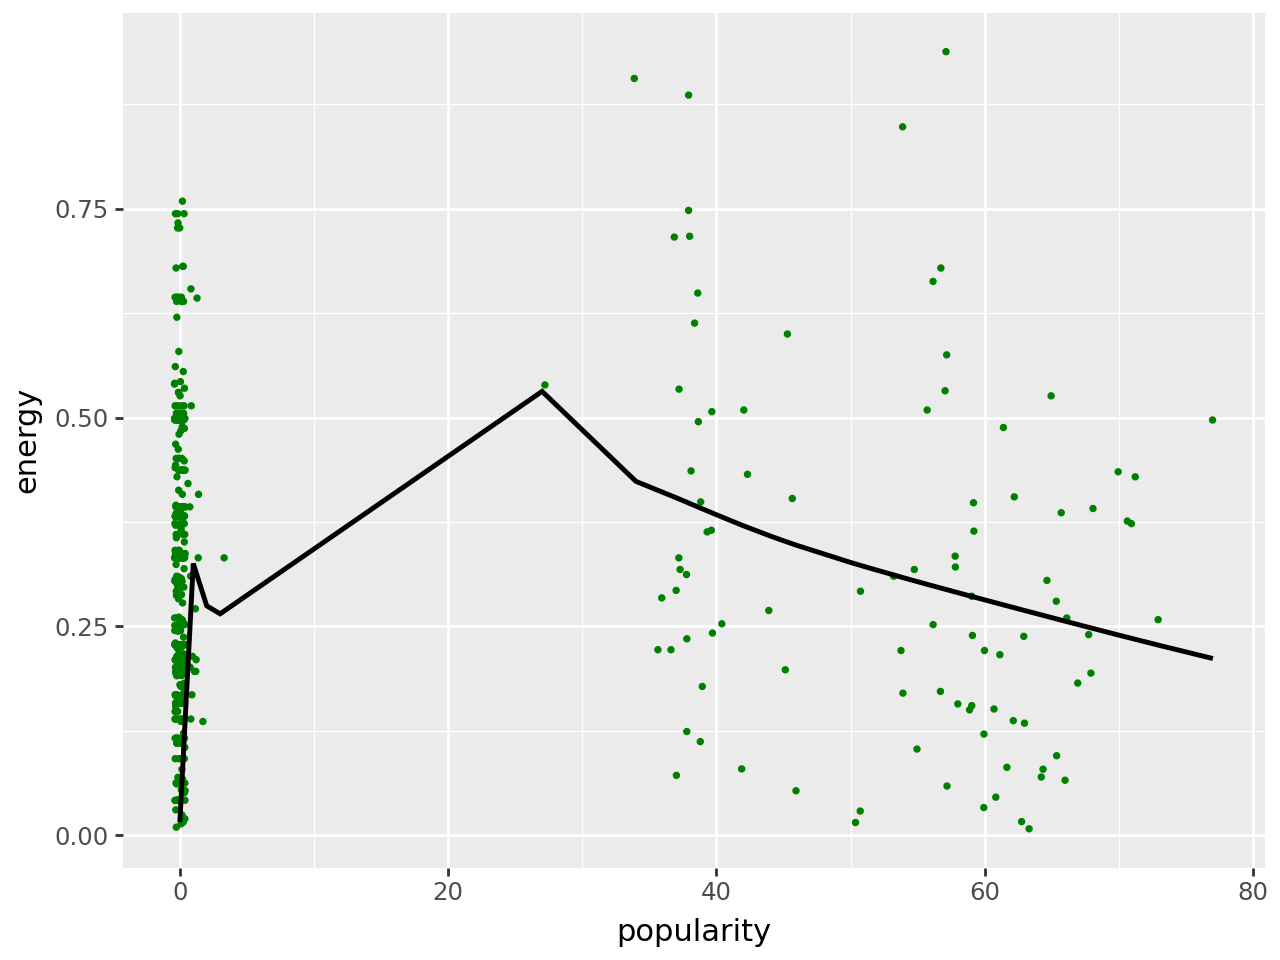

524


In [4]:
import plotnine as p9
from sklearn.model_selection import *
from sklearn.ensemble import RandomForestClassifier

#finding the graph from a specific genre and attribute
data_copy = data[data["track_genre"] == "jazz"]
display(
p9.ggplot(
data = data_copy,
    mapping = p9.aes(x='popularity', y='energy'))+
p9.geom_point(color="green", position="jitter", size=0.5) + p9.geom_smooth()
)

print((data["track_genre"] == "jazz").sum())

Plot for genre: acoustic


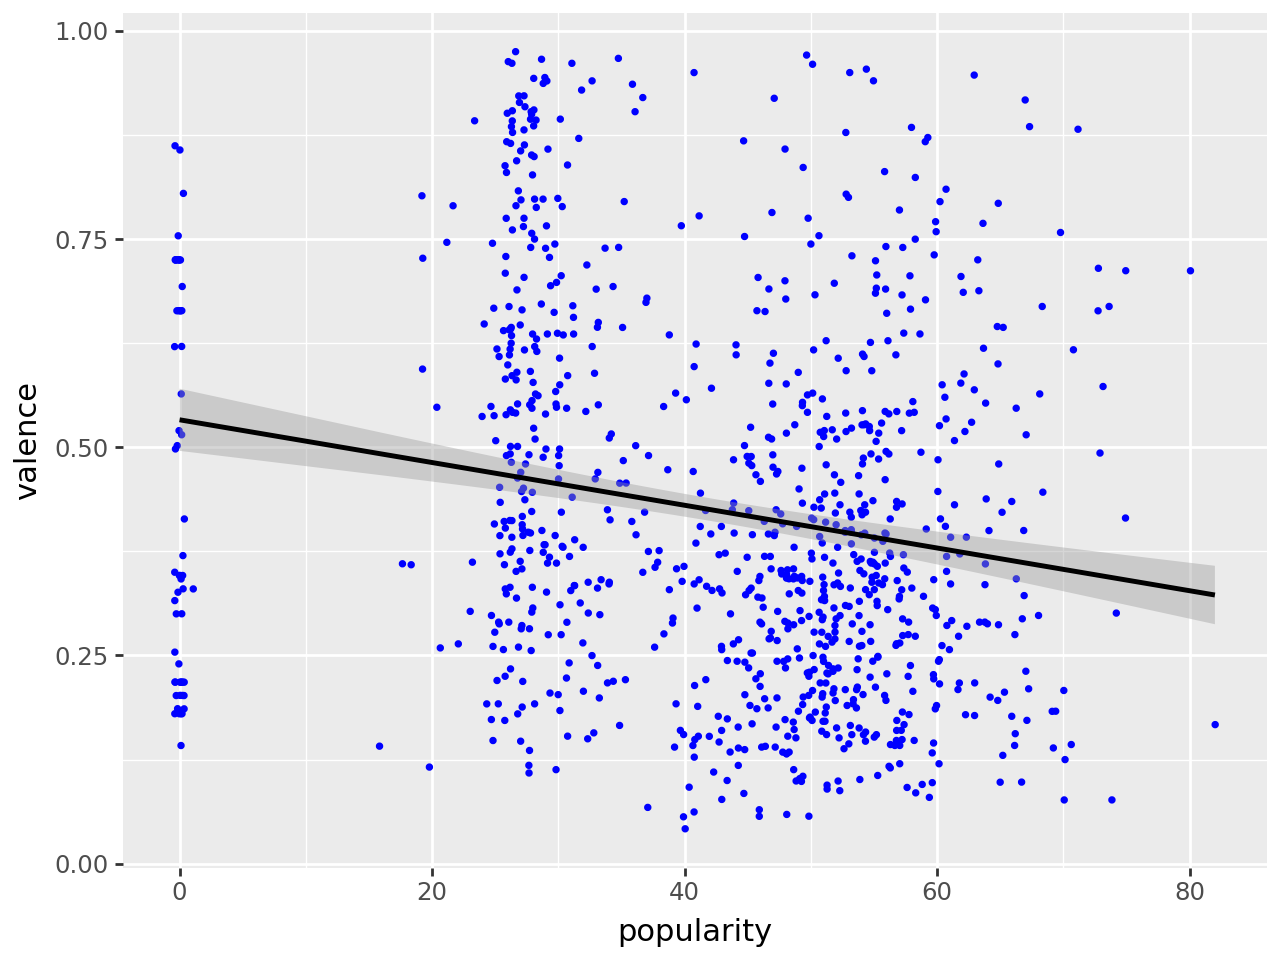

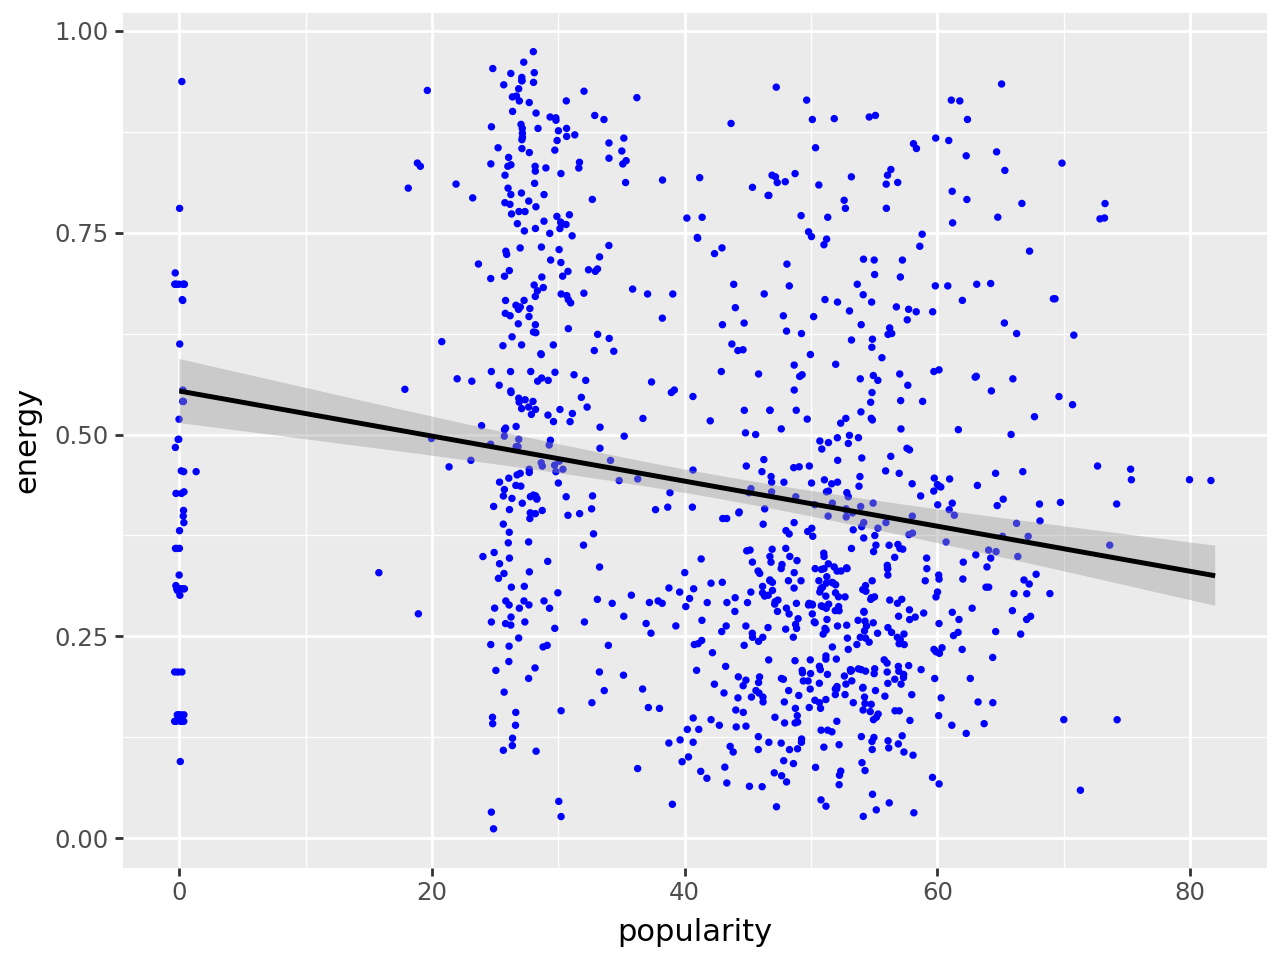

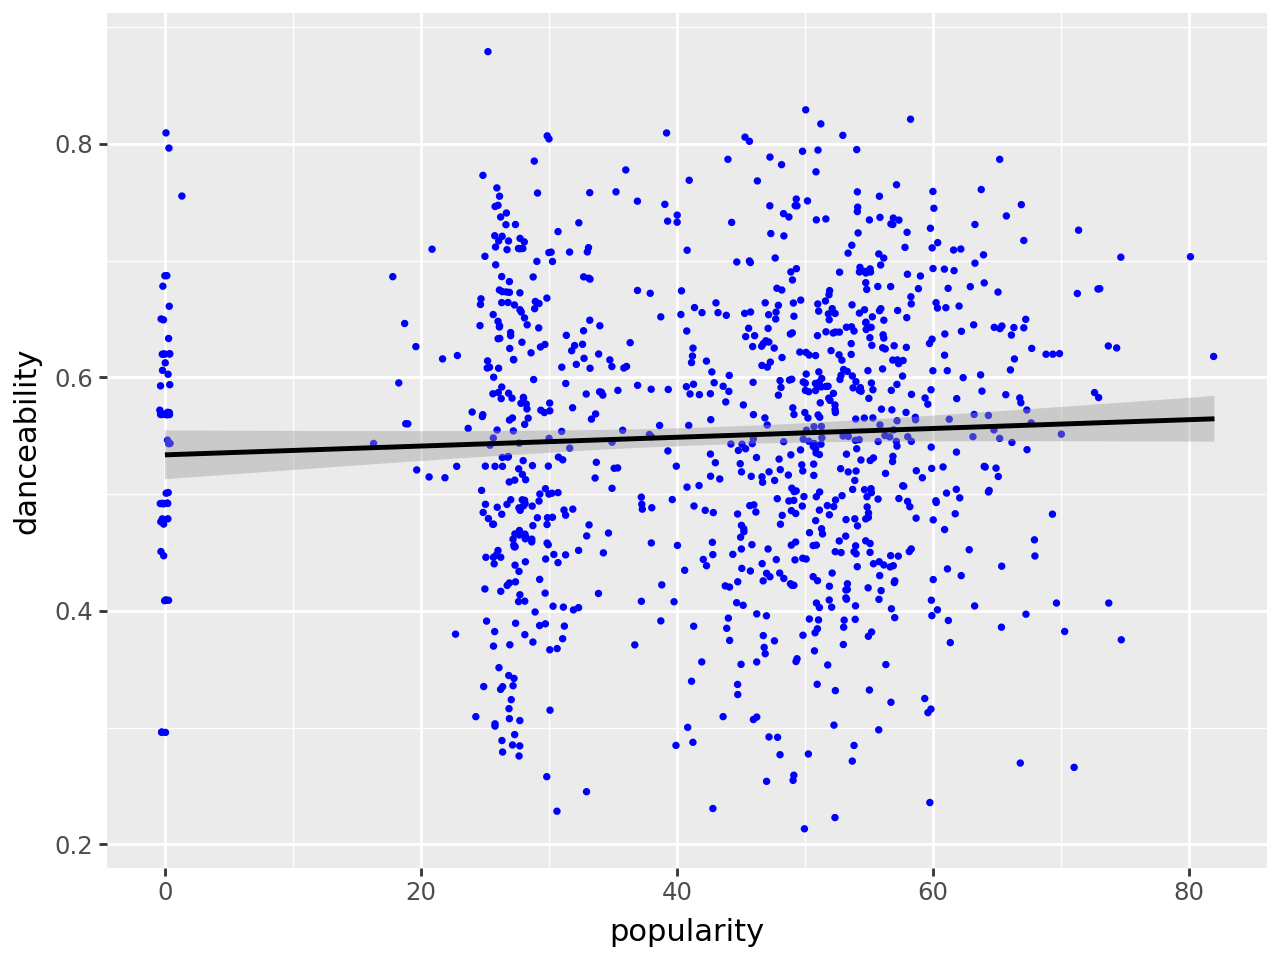

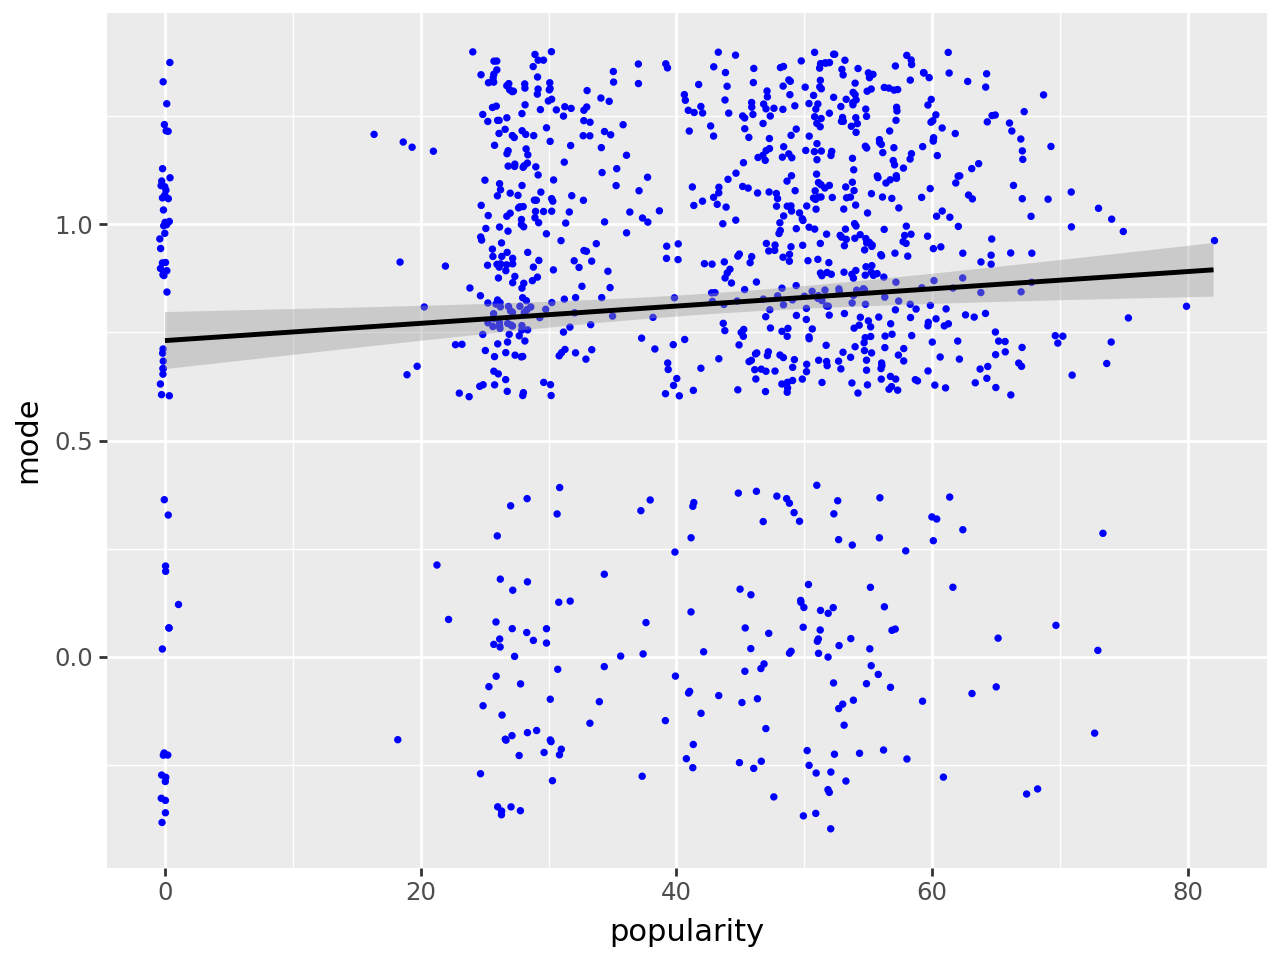

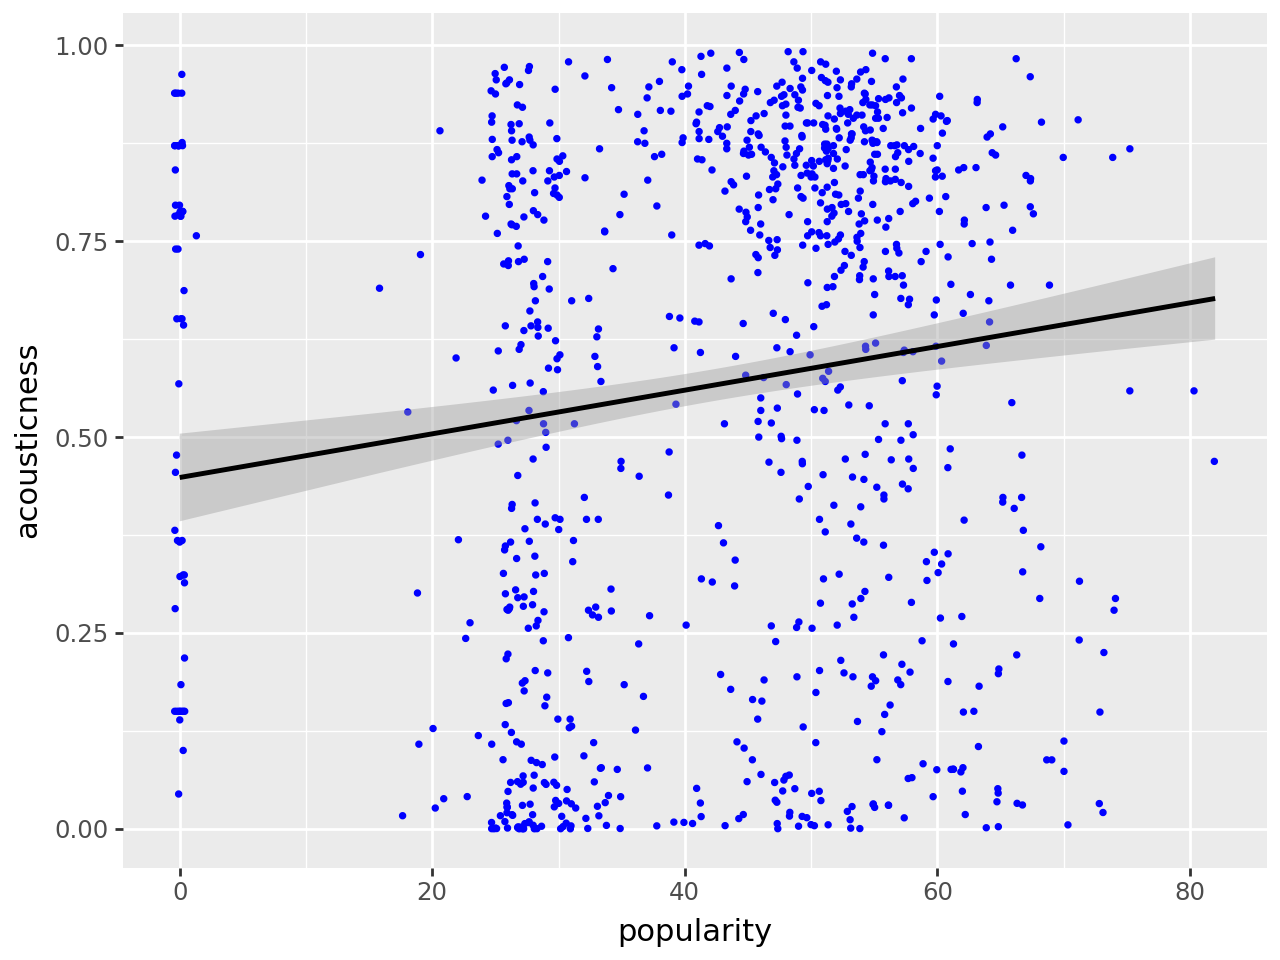

Plot for genre: afrobeat


C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


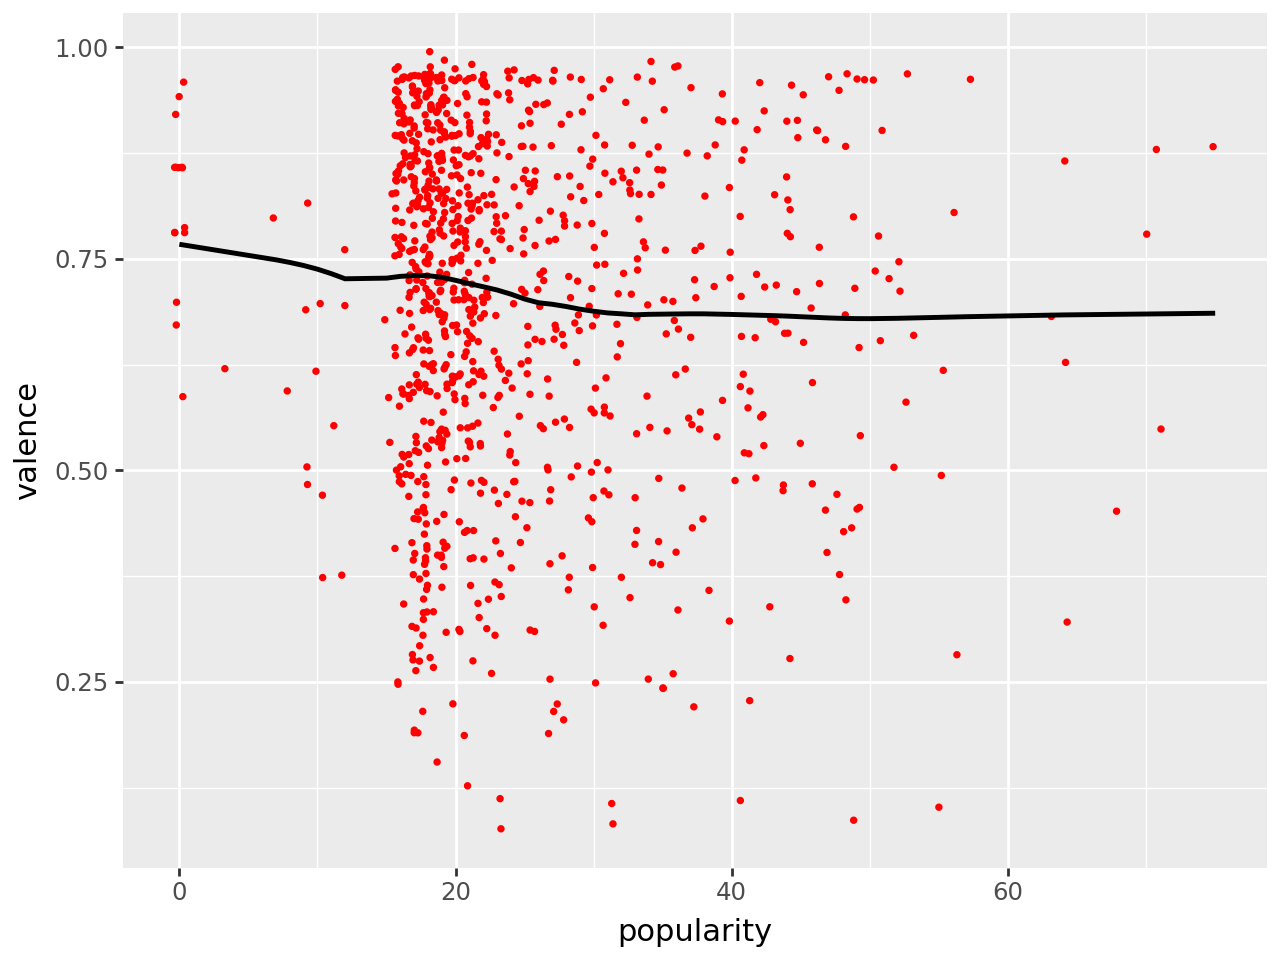

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


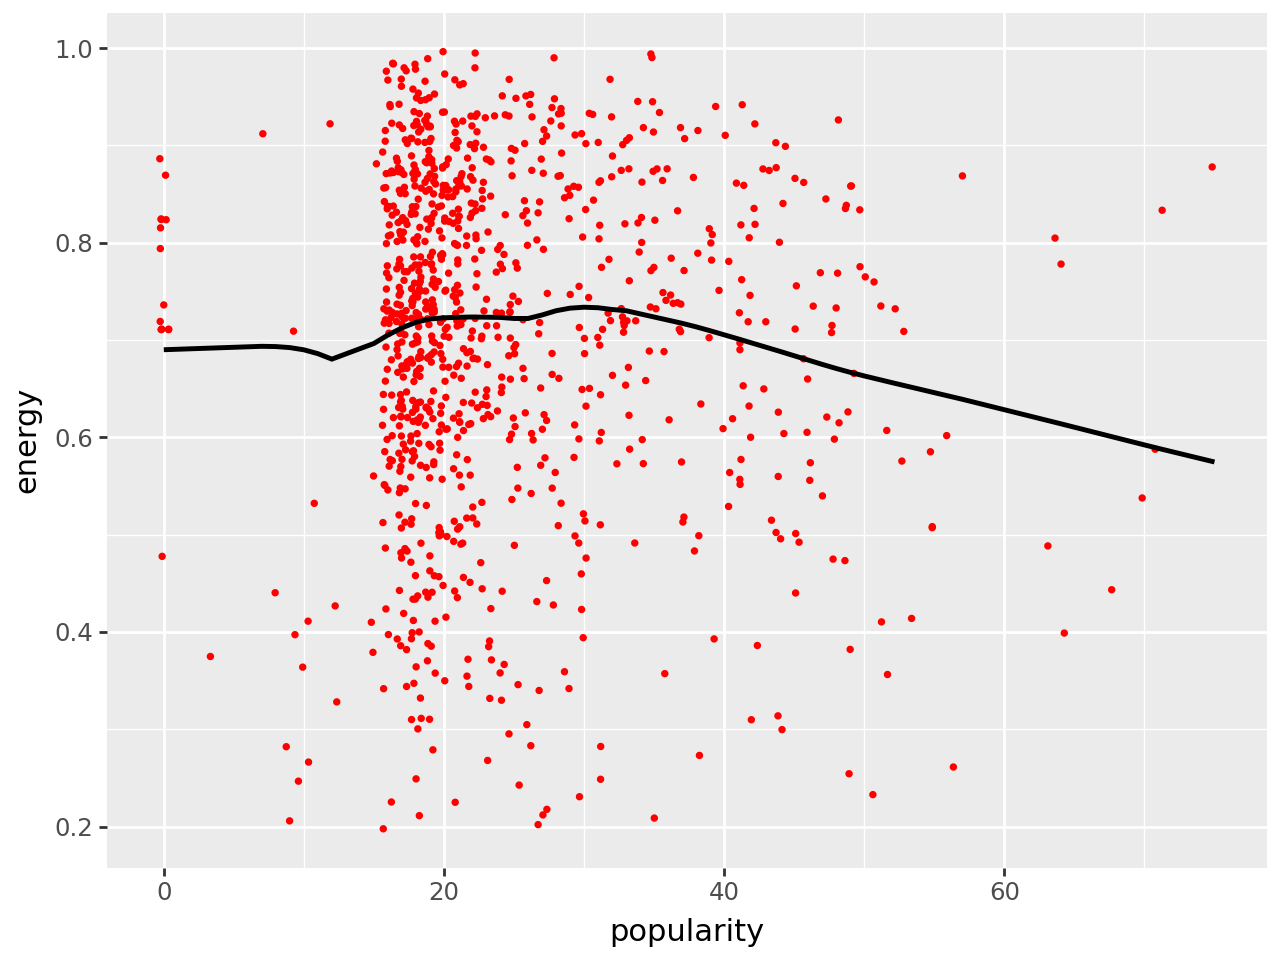

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


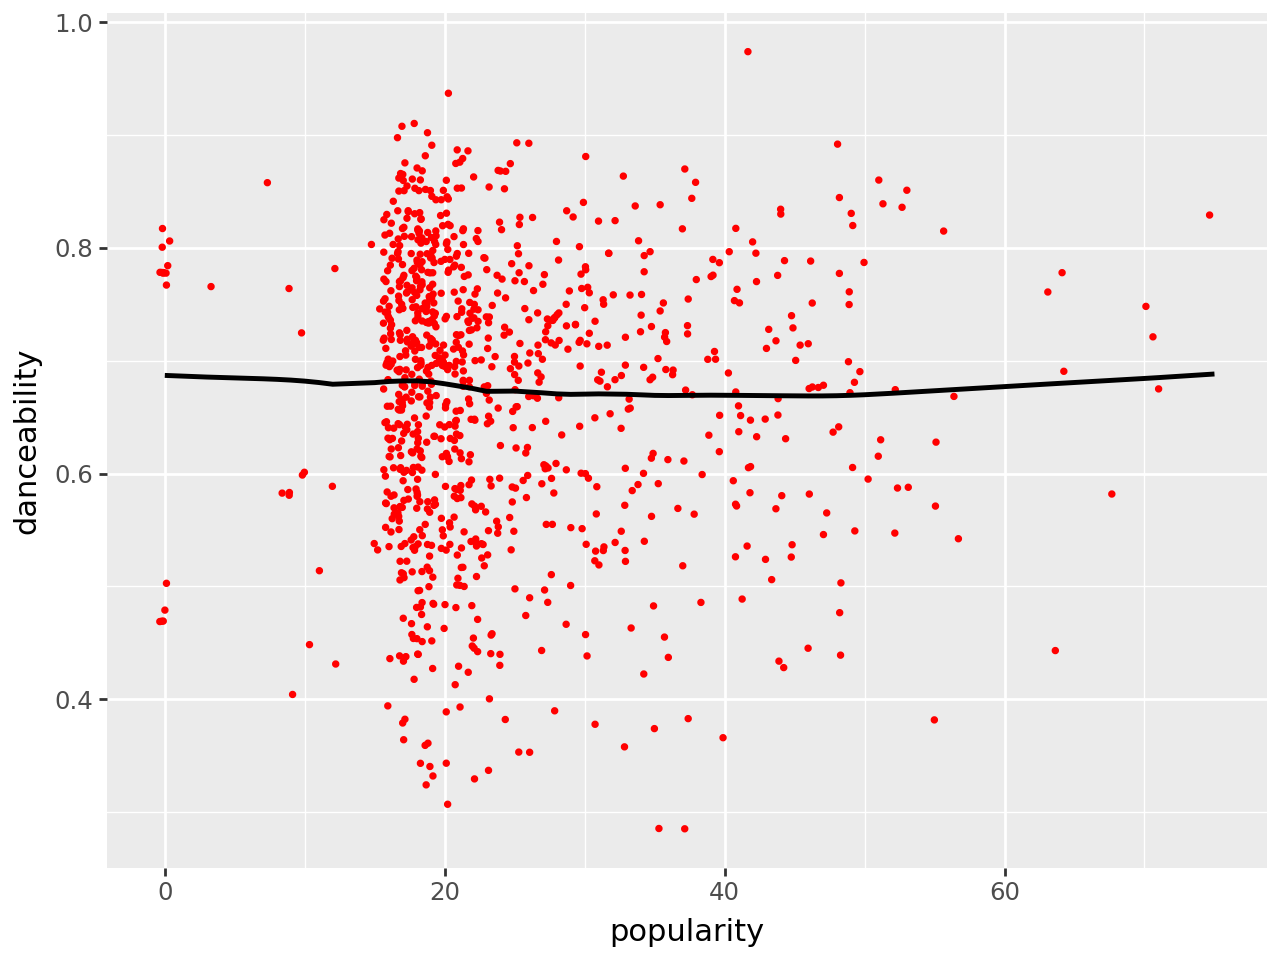

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


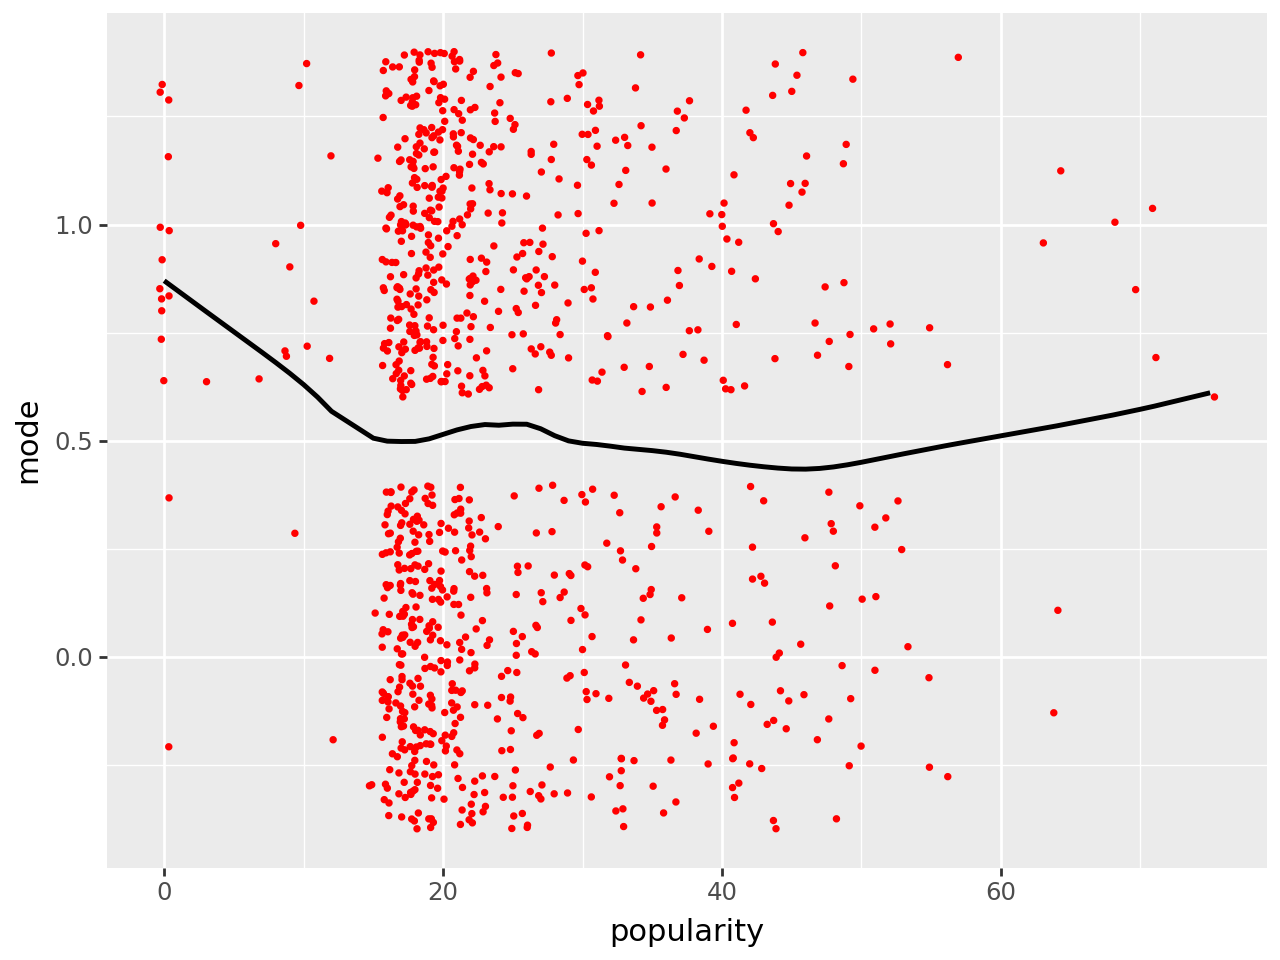

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


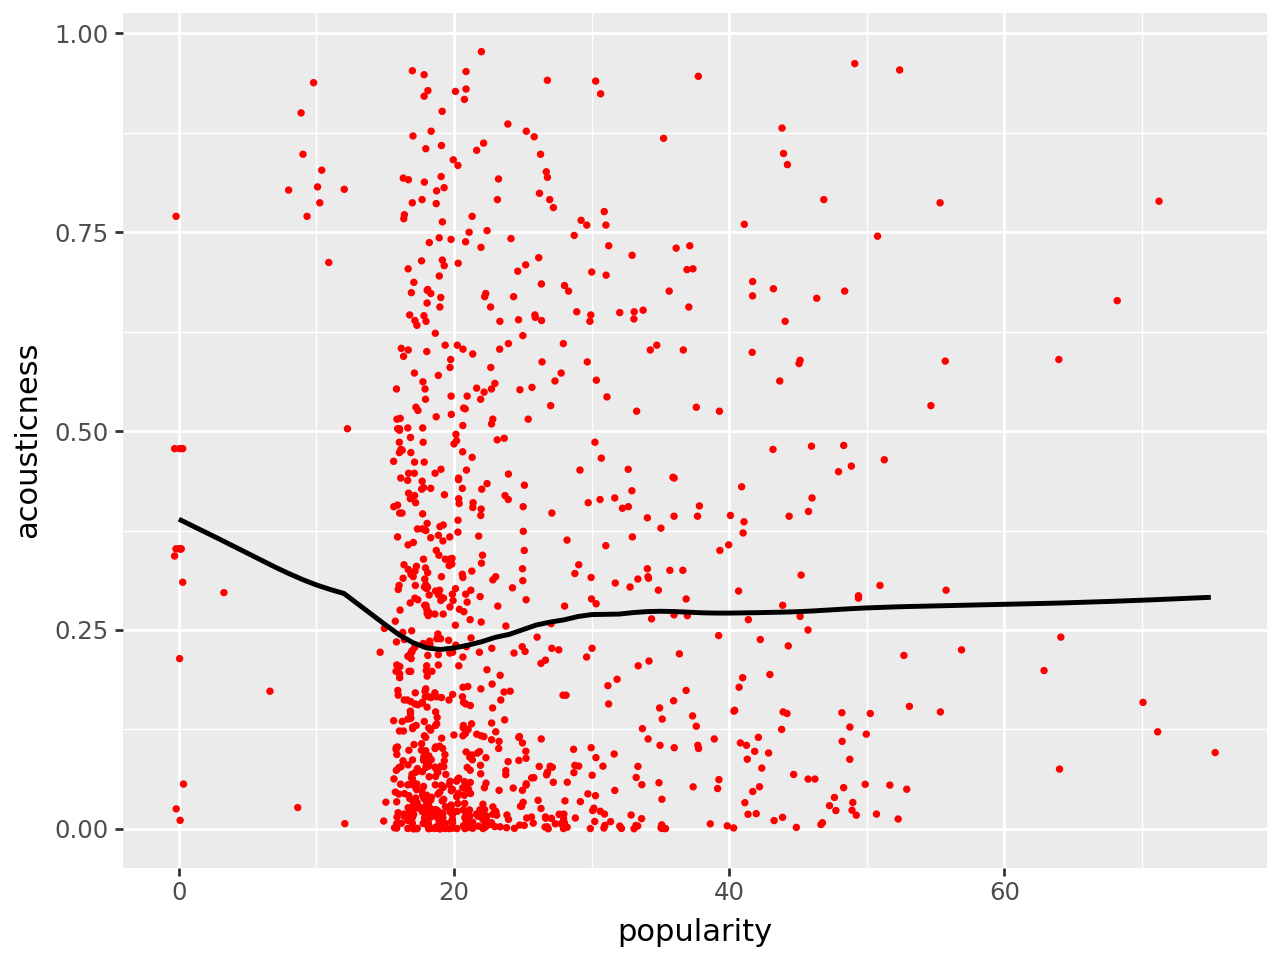

Plot for genre: alt-rock


C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


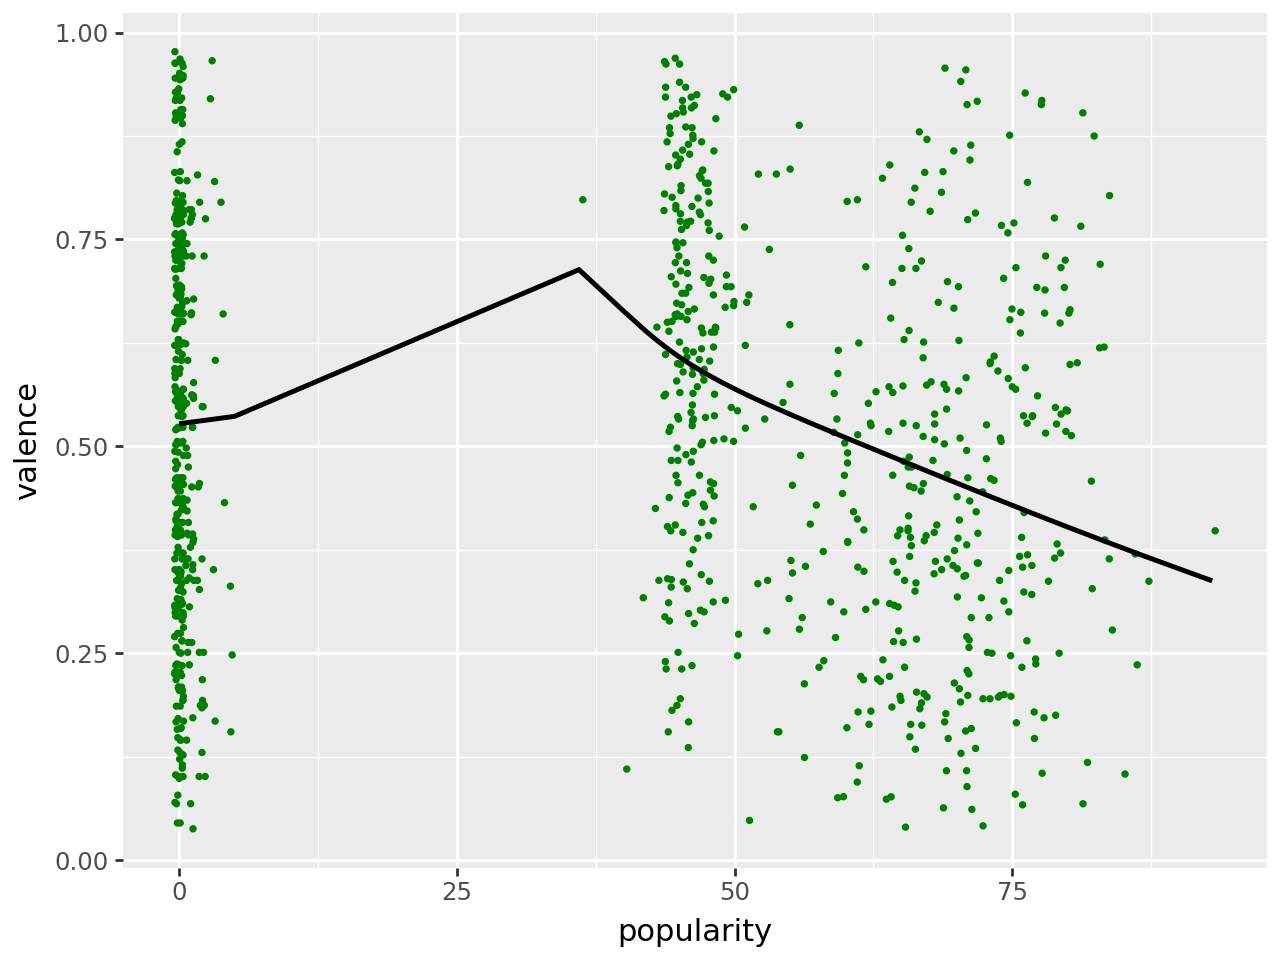

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


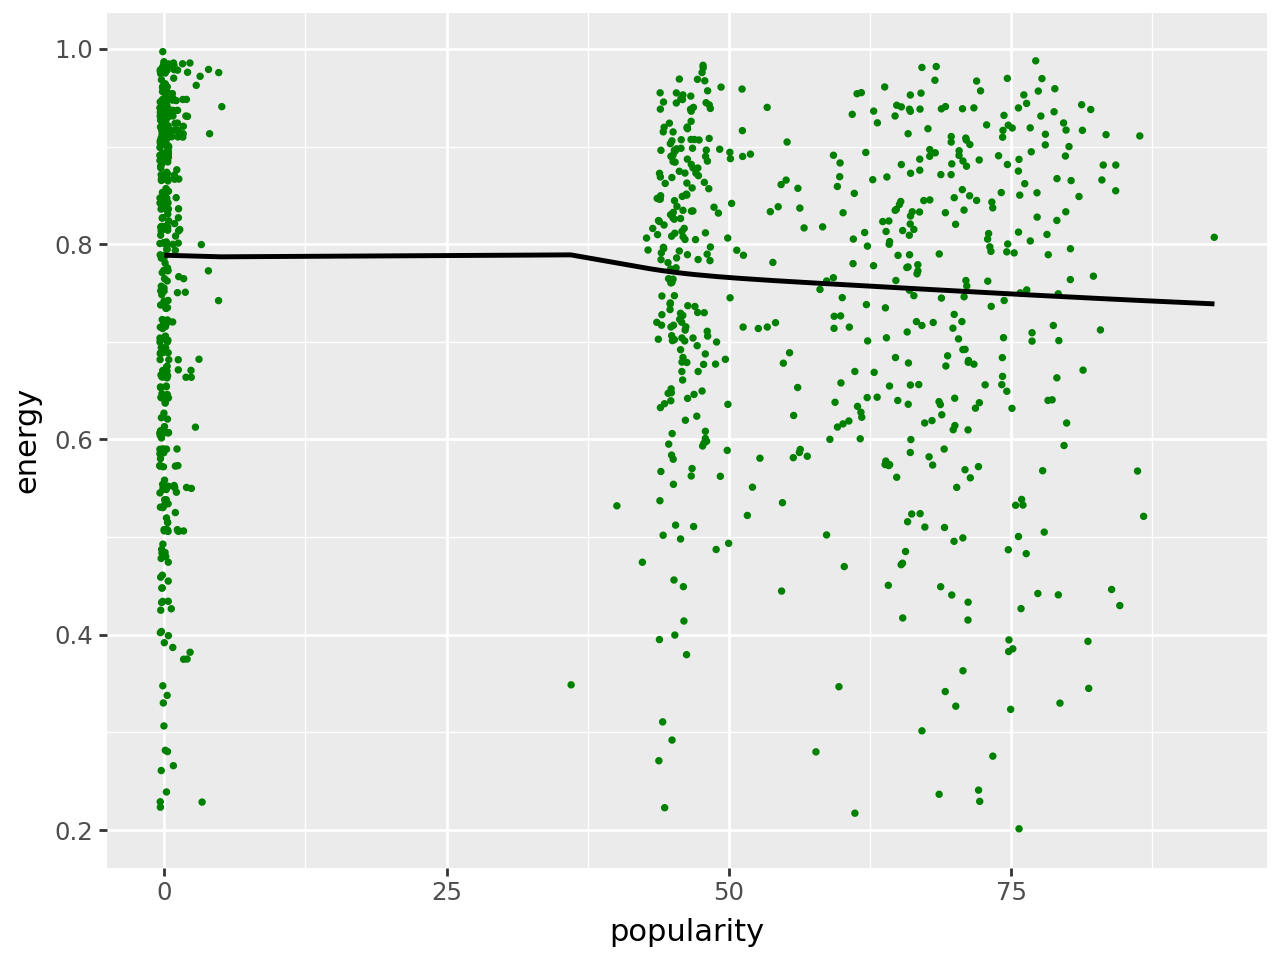

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


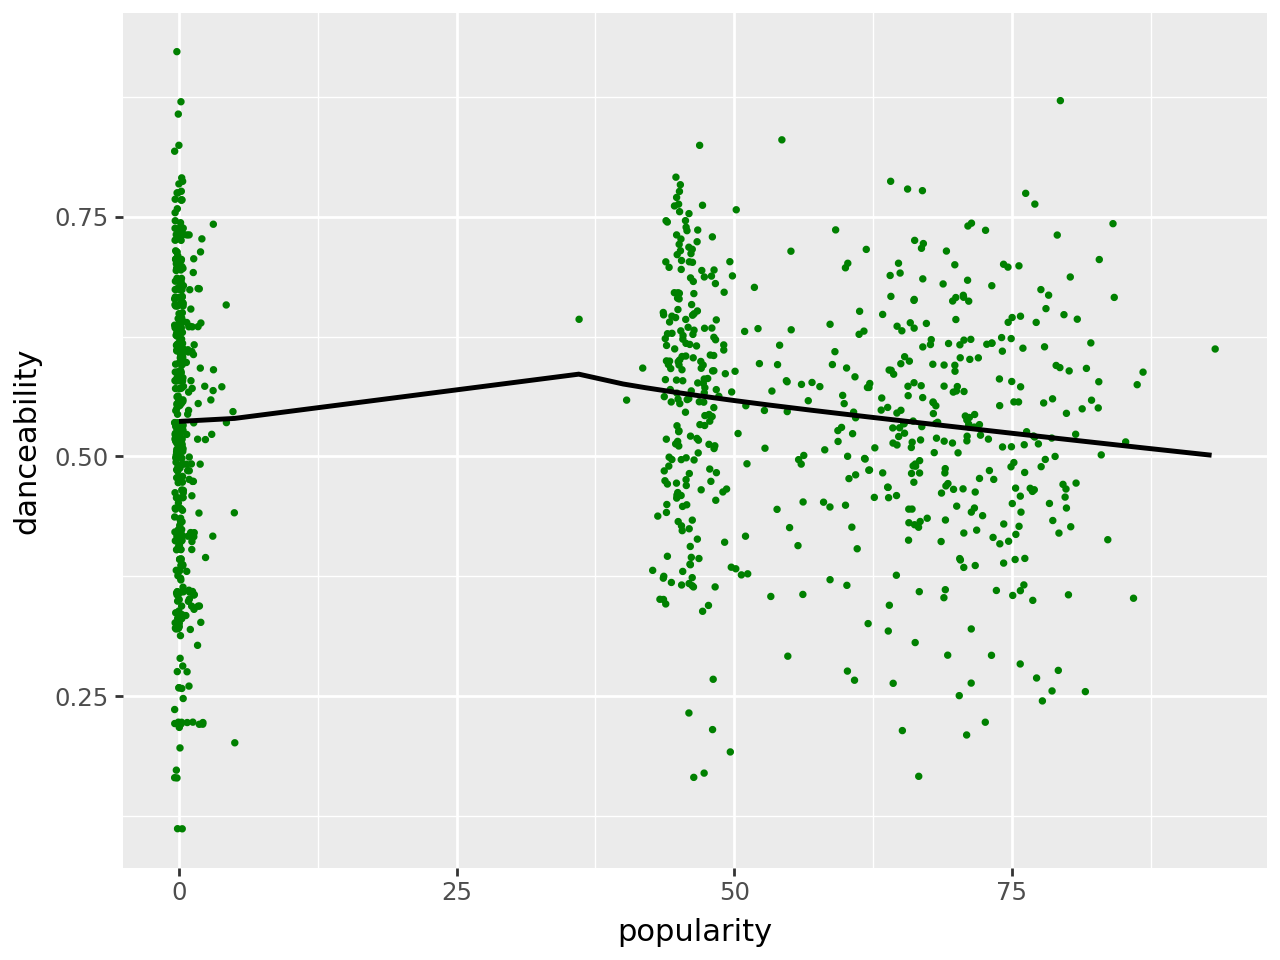

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


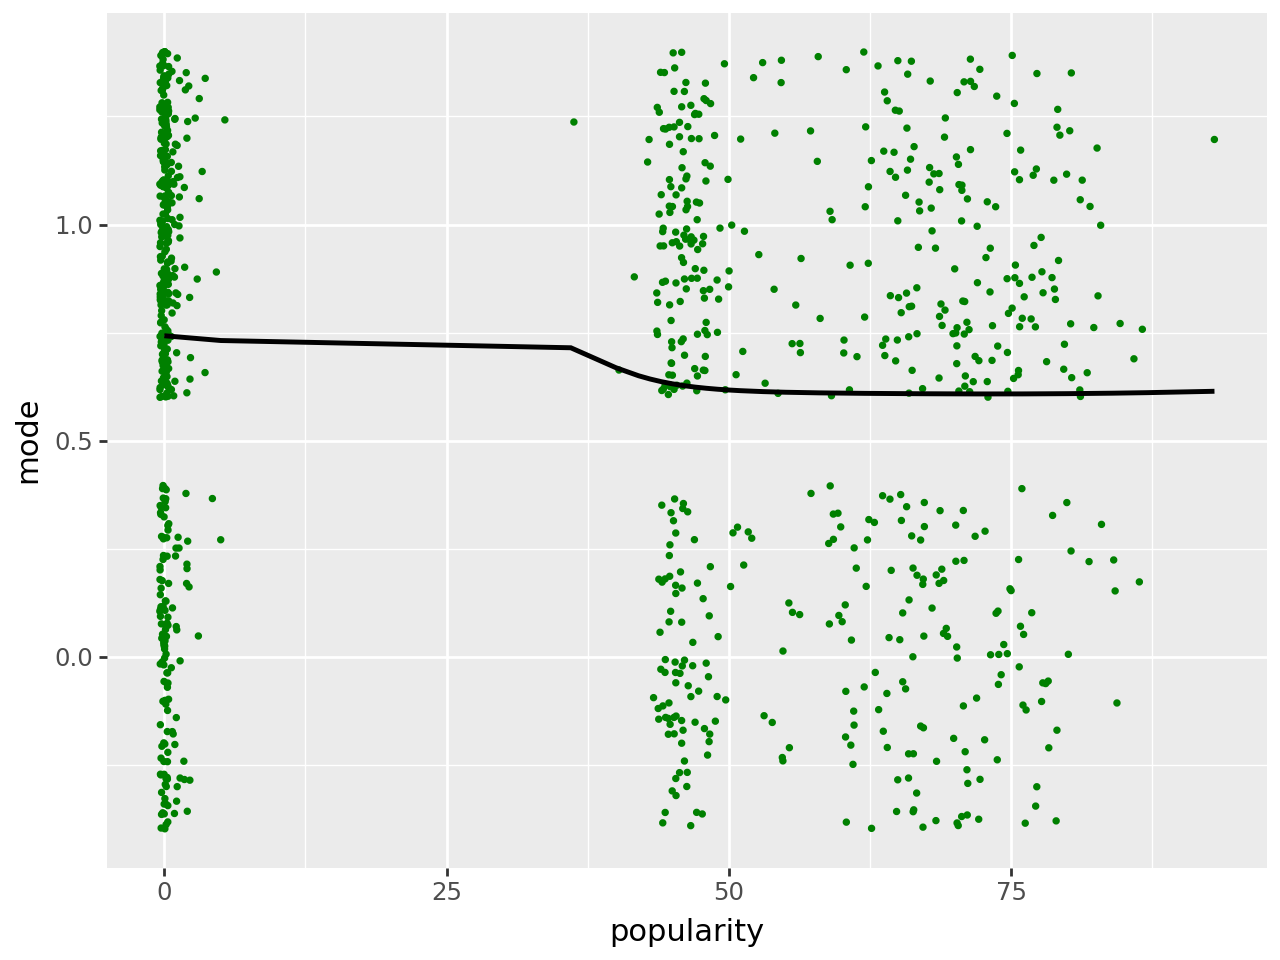

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


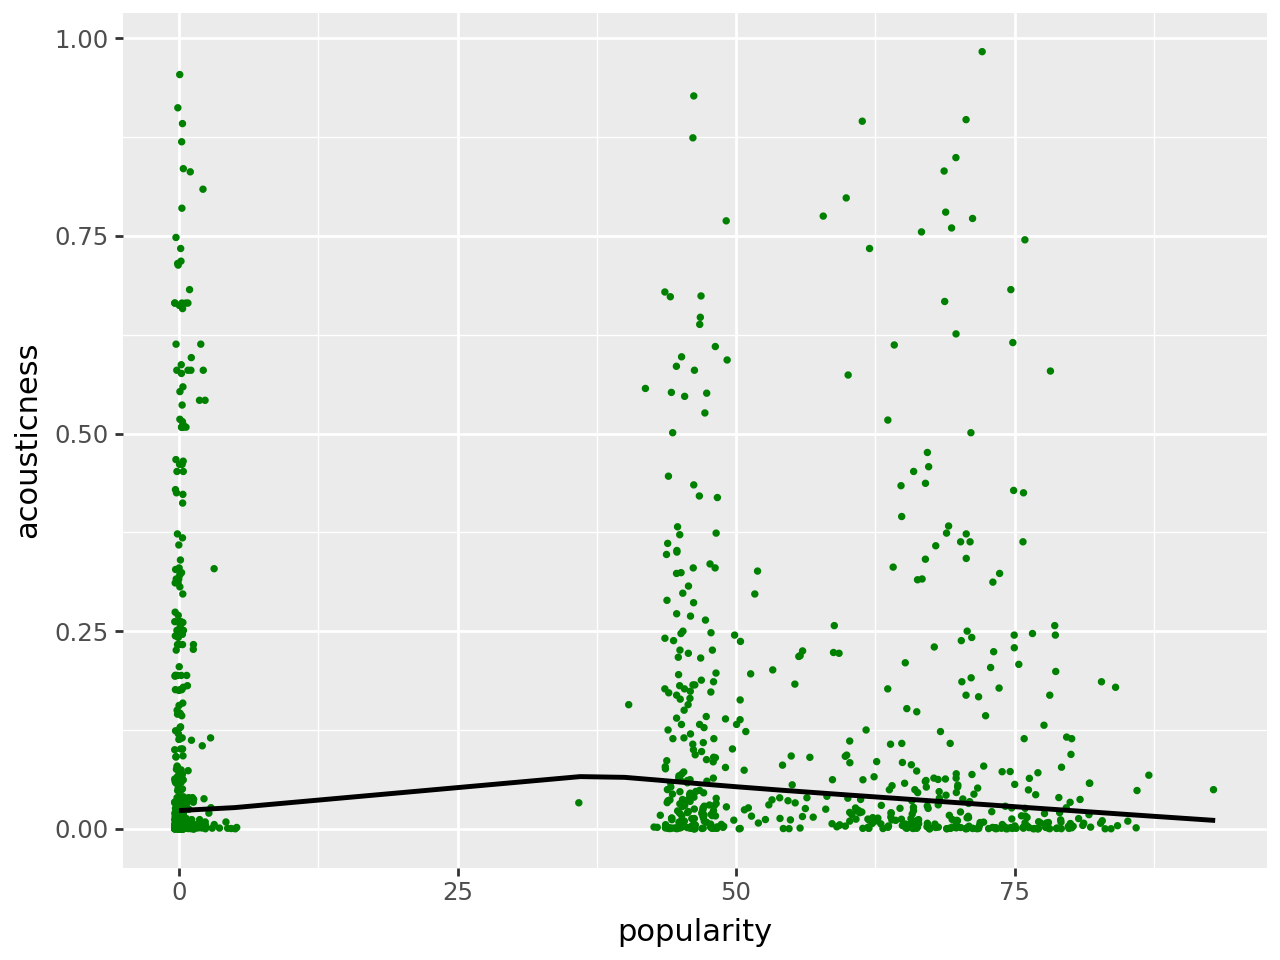

Plot for genre: ambient


C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


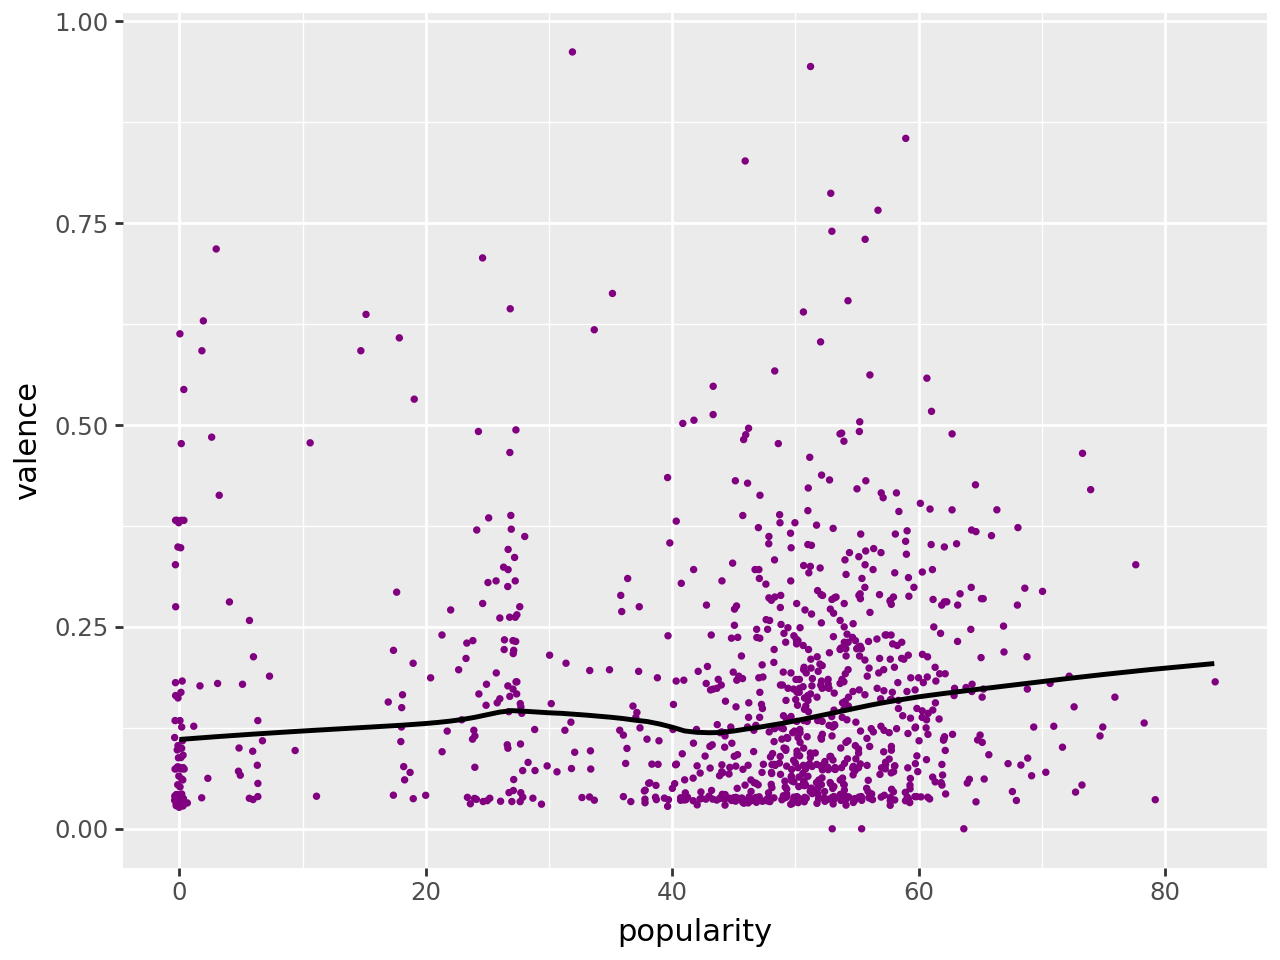

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


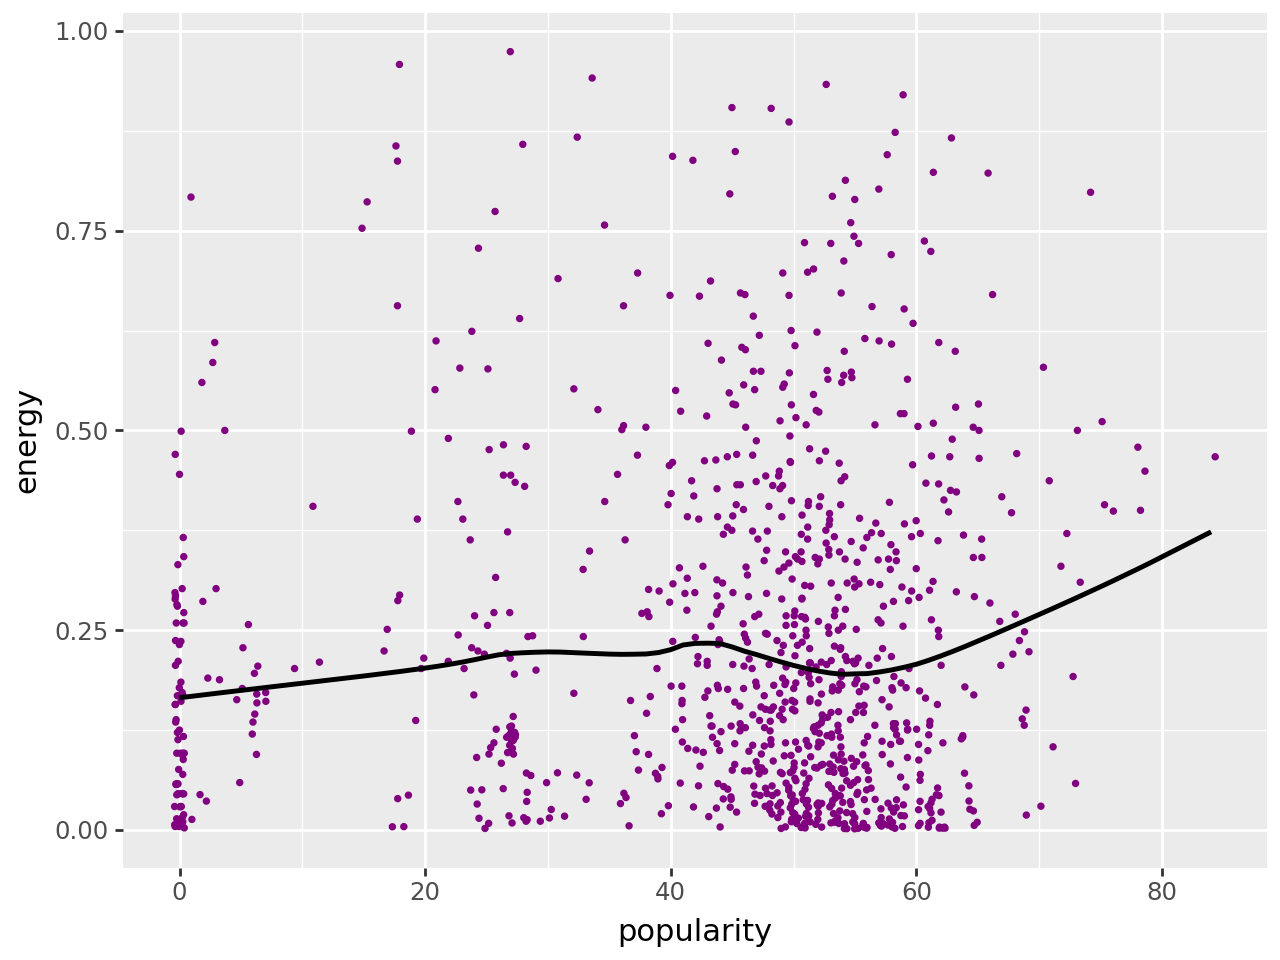

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


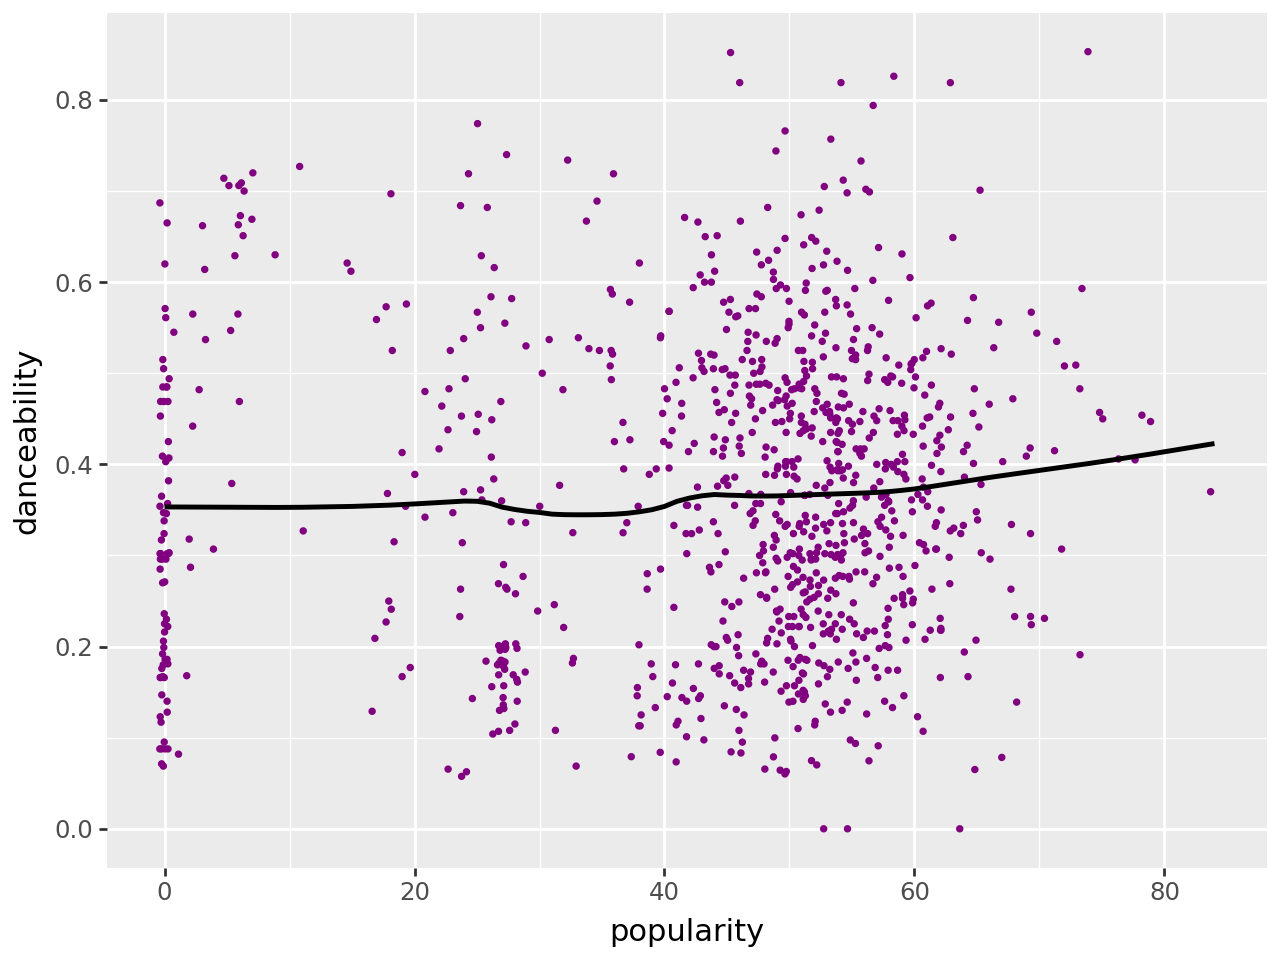

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


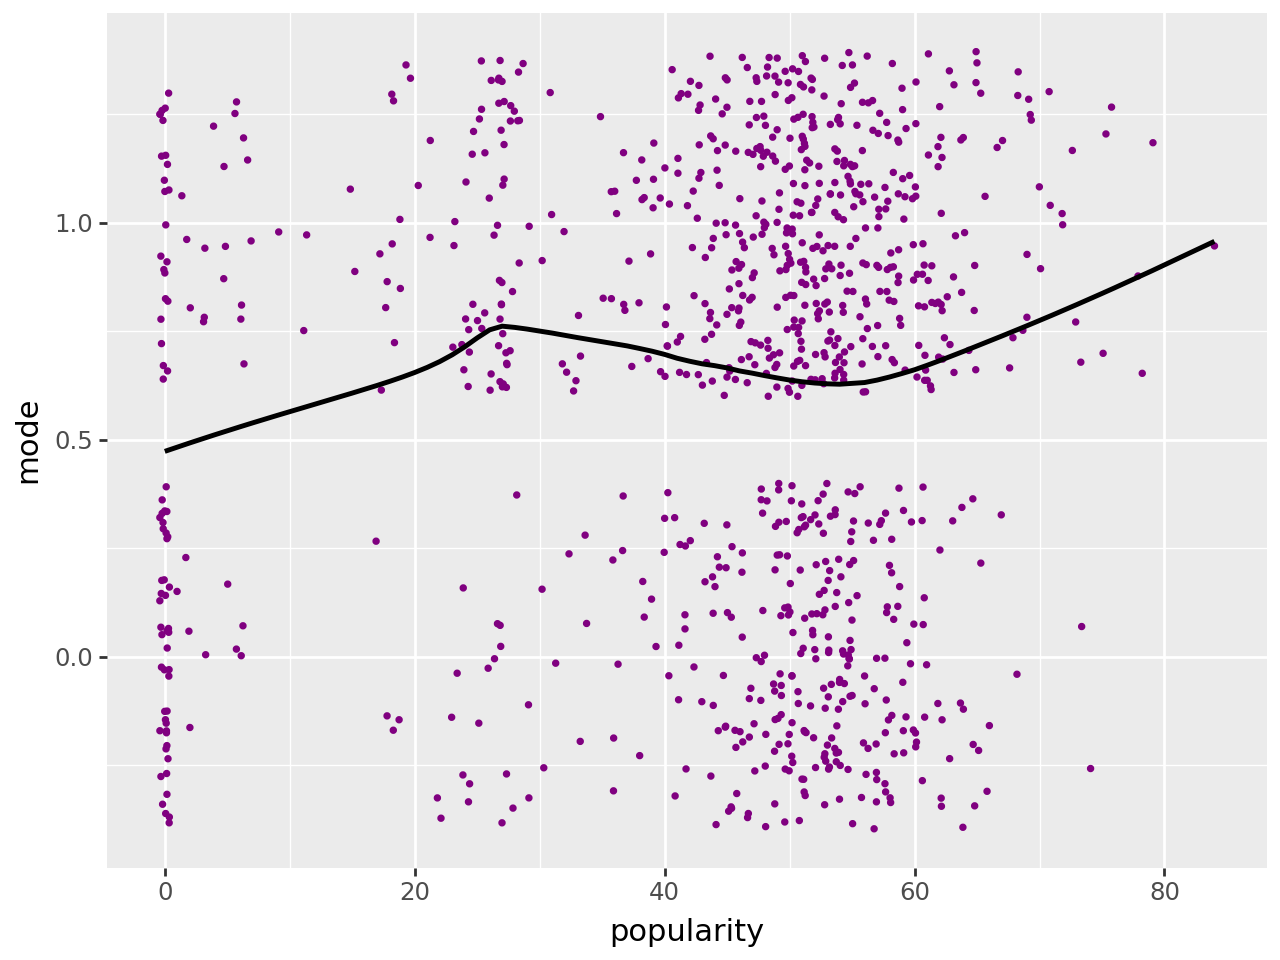

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


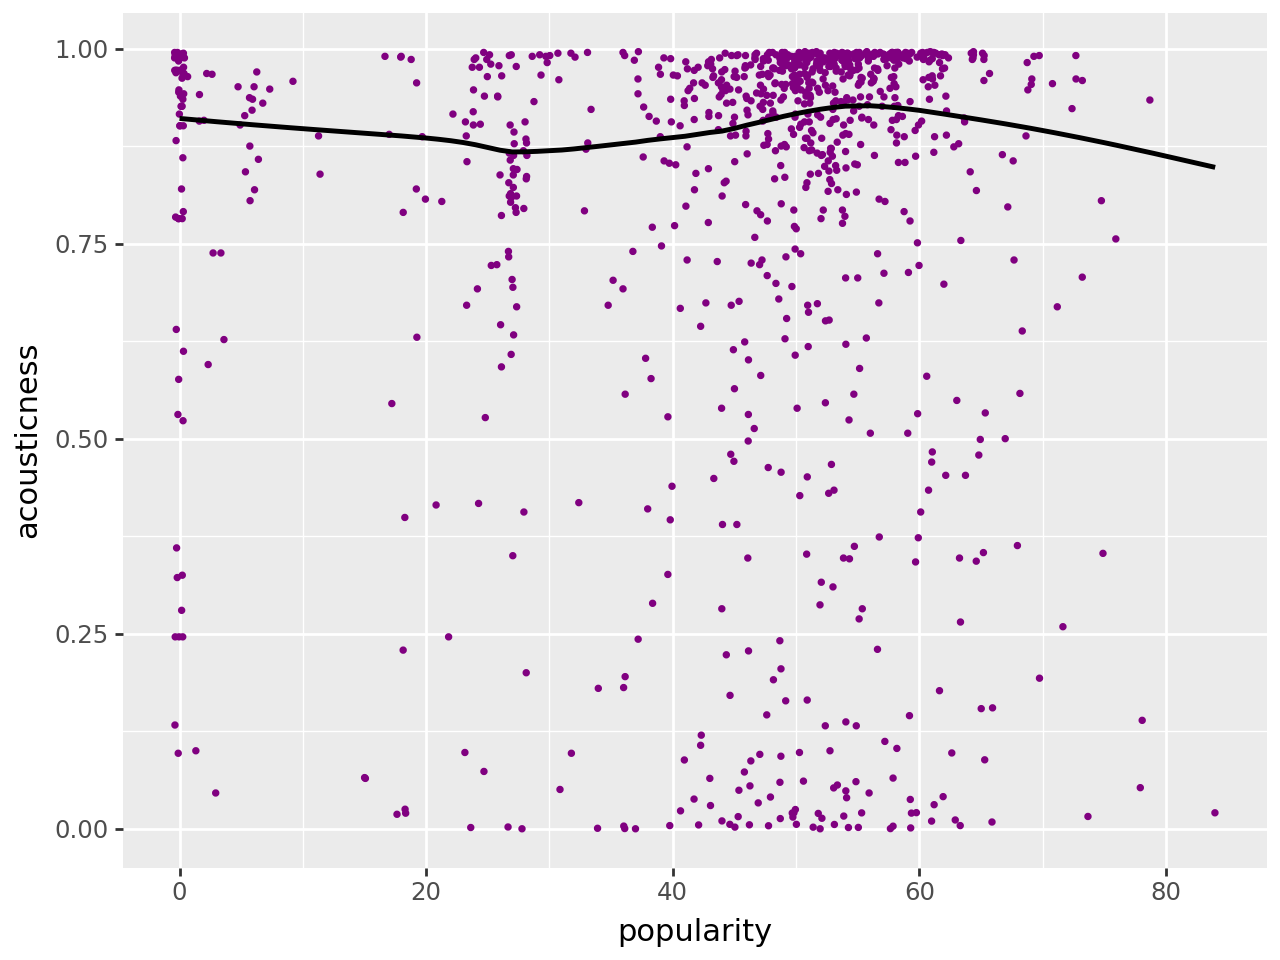

Plot for genre: cantopop


C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


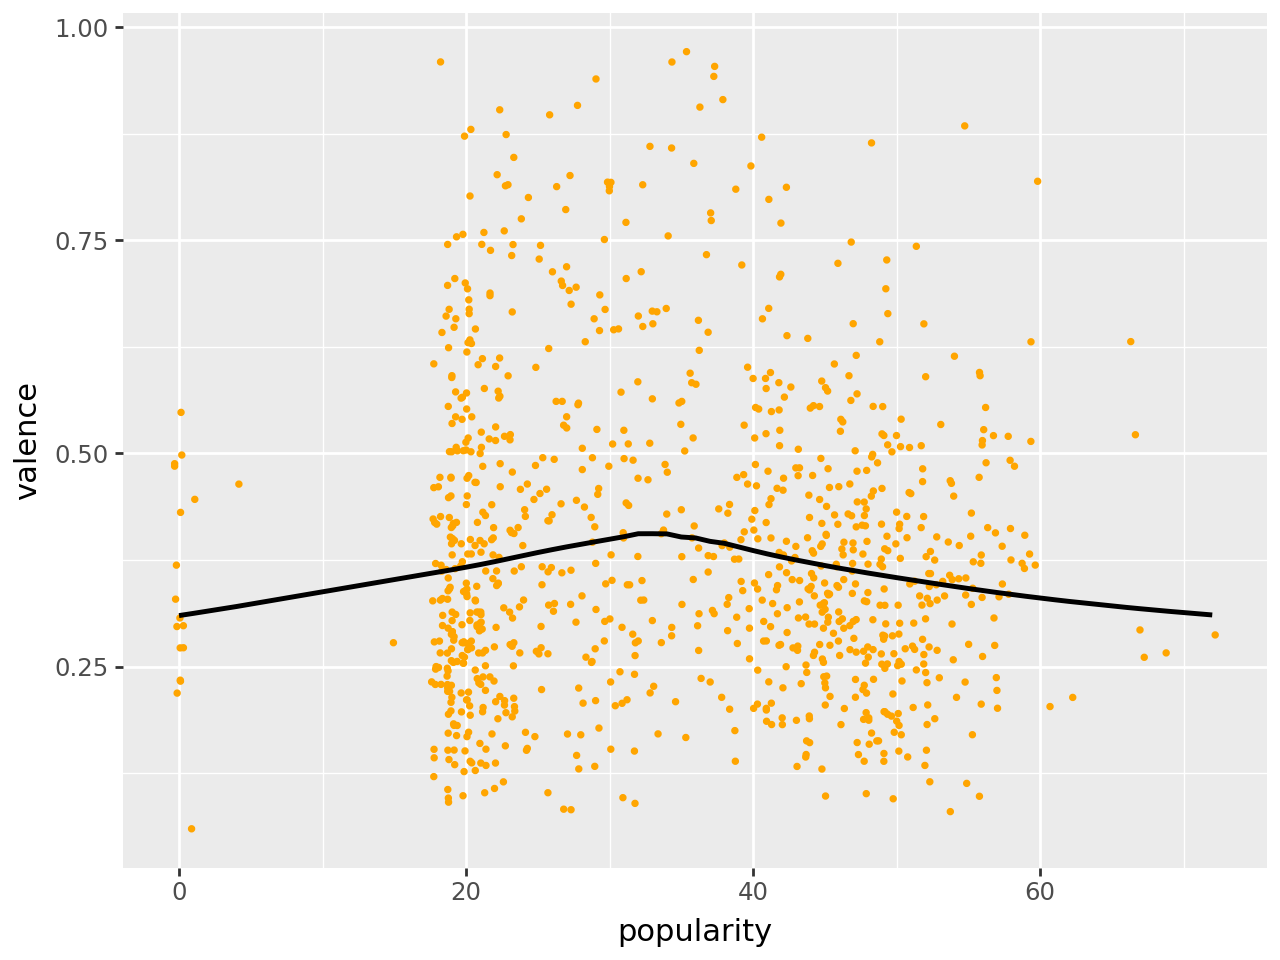

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


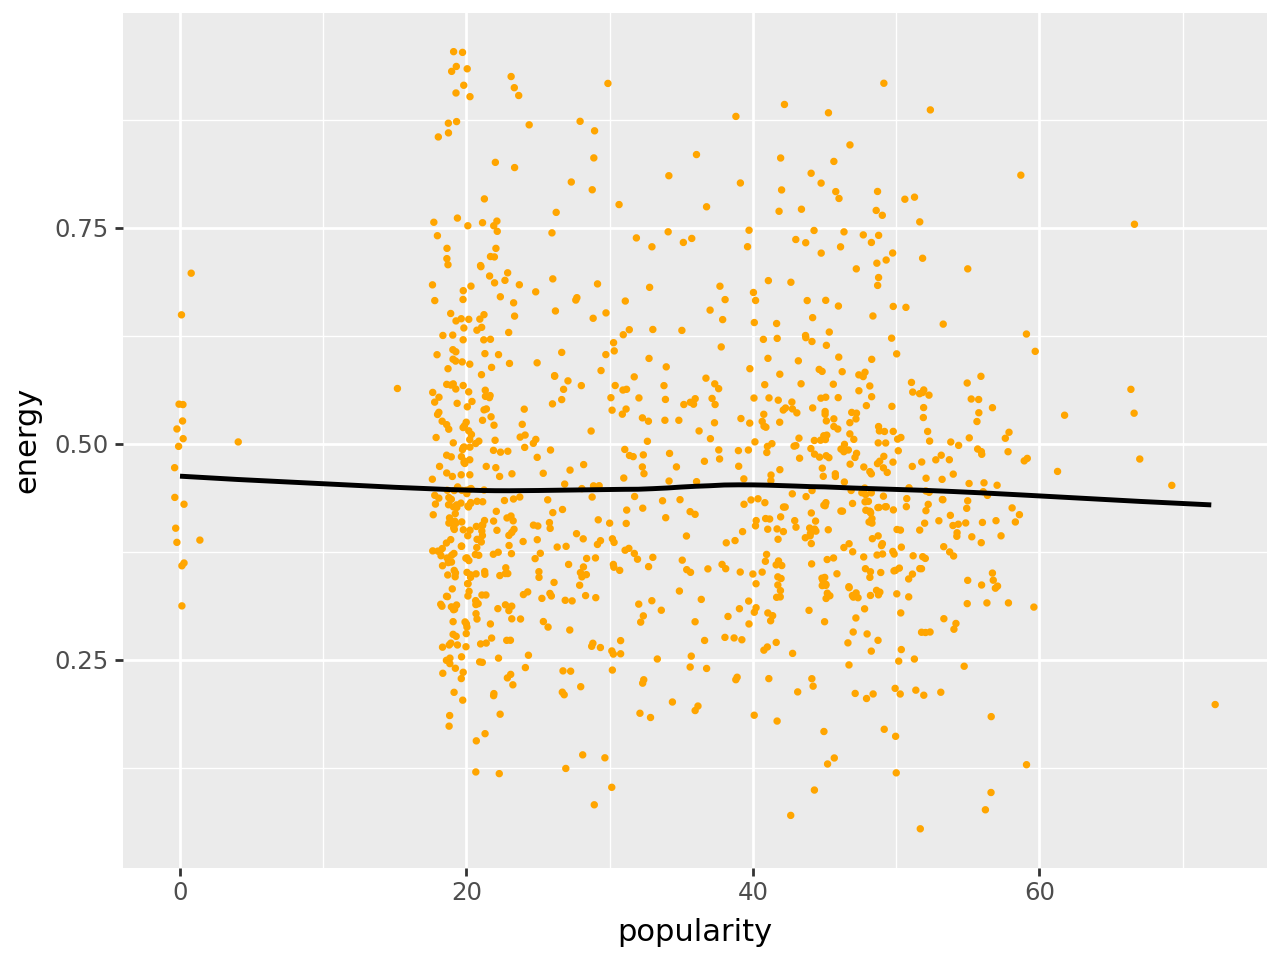

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


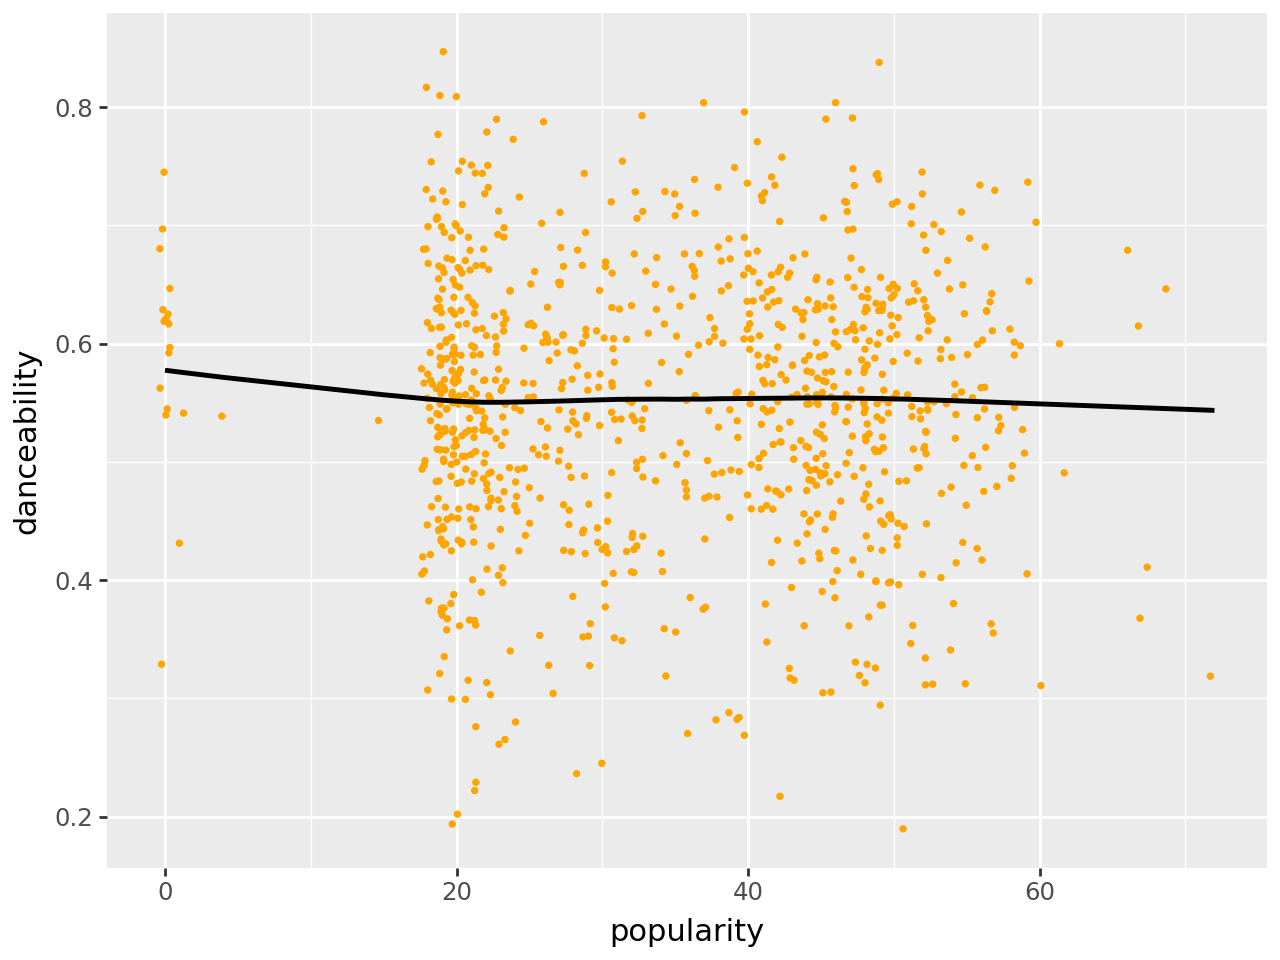

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


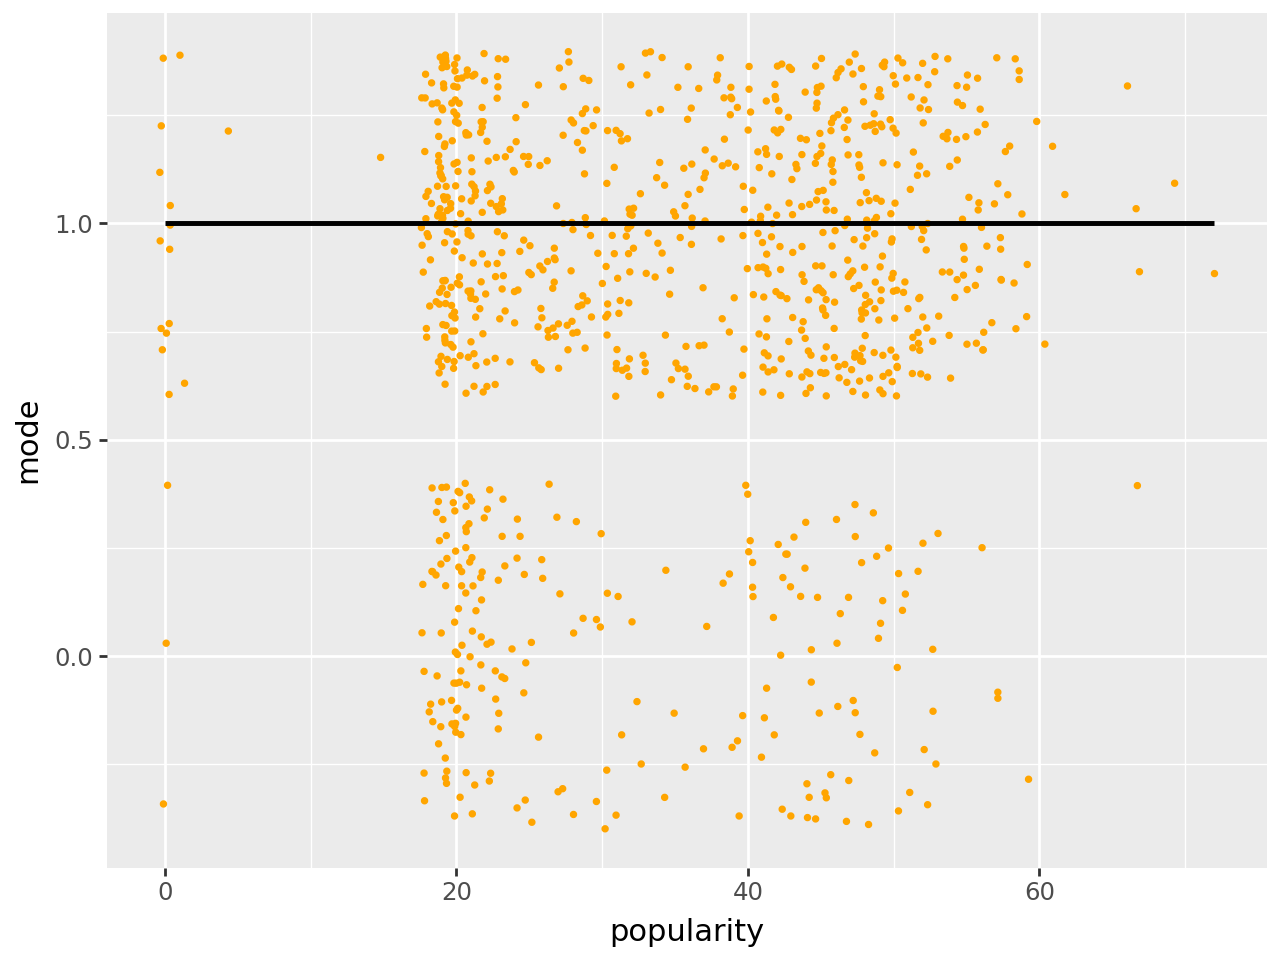

C:\Users\henrilipping\AppData\Local\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:345: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


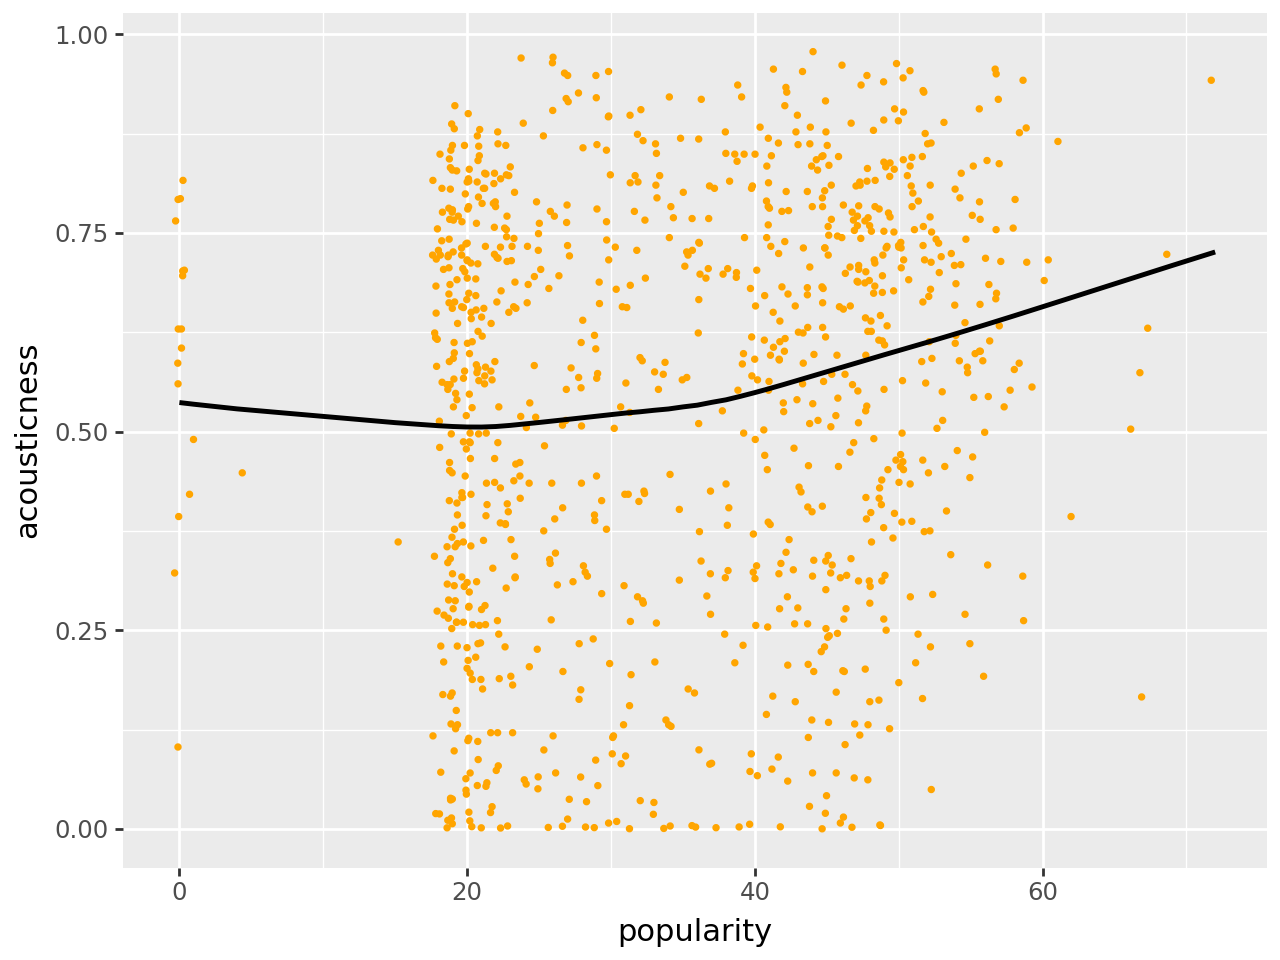

In [5]:
#method to find multiple graphs given 5 genres and attributes.
top5 = data['track_genre'].value_counts().head(5)
colors = ["blue", "red", "green", "purple", "orange"]
metadata = ["valence", "energy", "danceability", "mode", "acousticness"]

for i in range(5):
    genre = top5.index[i]
    data_copy = data[data["track_genre"] == genre]
    print(f"Plot for genre: {genre}")
    for j in range(5):
        display(
        p9.ggplot(
        data = data_copy,
        mapping = p9.aes(x='popularity', y=metadata[j]))+
        p9.geom_point(color=colors[i], position="jitter", size=0.5) + p9.geom_smooth()
        )

Method to predict using RandomForest and ALL genres, returns sorted DataFrame with accuracy and MSE for each genre. 
Code may run for up to a minute.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
unique_genres_list = data["track_genre"].unique().tolist()
#This now uses 4 bins to cut the popularity into 4 groups. Now the model doesnt have to predict 101 values but only 4.
data["pop_bin"] = pd.qcut(data["popularity"], q=4, labels=["Very Low", "Low", "High", "Very High"])#uus tulp mis splitb popularity põhjal, ehk cutoff 4'ga
def prediction(data, genres):
    results_df = pd.DataFrame({'genre': ['genre_name'], 'accuracy': ["acc"], "MSE": ["mse"]})
    for i in range(1,len(genres)):
        data_copy = data[data["track_genre"] == genres[i]]
        X = data_copy.drop("popularity", axis=1)  
        X = X.drop("pop_bin", axis=1)
        X = X.drop("track_id", axis=1)
        X = X.drop("artists", axis=1)
        X = X.drop("album_name", axis=1)
        X = X.drop("track_name", axis=1)
        X = X.drop("track_genre", axis=1)
        #y = data_copy["popularity"]
        y = data_copy["pop_bin"] #ennustame nüüd uud tulpa, mitte popularity.
        X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
        rf = RandomForestClassifier().fit(X_train, y_train) # Testisime erinevaid randomforestclassifiereid ning tuli välja, et tüli ehk vaikimisi on kõike täpsem meie mudeli puhul
        pred = rf.predict(X_test)
        acc = accuracy_score(y_test, pred)
        #mse = mean_squared_error(y_test, pred)
        #mse vist ei tööta millegipärast
        #ikka kasutab Classifier
        results_df.loc[len(results_df)] = [genres[i], acc, 0]
    results_df = results_df.drop(0, axis=0).reset_index(drop=True)
    results_df_sorted = results_df.sort_values(by='accuracy', ascending=False)
    return results_df_sorted


result = prediction(data, unique_genres_list)
print(result) 
print("Average accuracy: " + str(result['accuracy'].mean()))
#print(result[result["genre"] == "jazz"])
#print("Average MSE: " + str(result['MSE'].mean()))

        genre  accuracy MSE
39     gospel       1.0   0
58    iranian       1.0   0
79   pop-film  0.981595   0
92    romance  0.972376   0
95      samba  0.968504   0
..        ...       ...  ..
0    afrobeat      0.46   0
11   cantopop      0.44   0
103     study      0.41   0
109  trip-hop  0.359116   0
56      indie  0.333333   0

[112 rows x 3 columns]
Average accuracy: 0.6906449991096519


Next we built two function that predicts a song popularity based on "duration_ms", "explicit", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature". First one predicts with pop_bin where popularity is devided into 4 difference selectors and second function predicts with popularity (0-100). We built both to see does one works better than the another.

In [7]:
def predict_song_popularity(numeric_columns, song_genre, song_data):
    # Takes only predicted song gender
    data_copy = data[data["track_genre"] == song_genre]

    # Takes columns where are only numeric values
    X_full = data_copy[numeric_columns]
    y_full = data_copy["pop_bin"]
    
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
    
    model = RandomForestClassifier().fit(X_train_full, y_train_full)

    # Create a one-row DataFrame from song_data
    df_song = pd.DataFrame([song_data])
    prediction = model.predict(df_song)[0]
    
    return(prediction)

In [8]:
def predict_song_popularity2(numeric_columns, song_genre, song_data):
    # Takes only predicted song gender
    data_copy = data[data["track_genre"] == song_genre]

    # Takes columns where are only numeric values
    X_full = data_copy[numeric_columns]
    y_full = data_copy["popularity"]
    
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor().fit(X_train_full, y_train_full)

    # Create a one-row DataFrame from song_data
    df_song = pd.DataFrame([song_data])
    prediction = model.predict(df_song)[0]
    
    return(prediction)

Now we give value to numberic_columns

In [9]:
# Numeric column values
numeric_columns = ["duration_ms", "explicit", "danceability", "energy", "key", "loudness", "mode", "speechiness",  
                    "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature"]

Next we can select one song data in database and see how well does prediction match with original song popularity

In [10]:
# Predicted song data 33
song_genre = "iranian"
song_data = {
    "duration_ms": 537610,
    "explicit": 0,
    "danceability": 0.101,
    "energy": 0.103,
    "key": 5,
    "loudness": -20.407,
    "mode": 1,
    "speechiness": 0.0449,
    "acousticness": 0.97,
    "instrumentalness": 0.93,
    "liveness": 0.0922,
    "valence": 0.0334,
    "tempo": 83.575,
    "time_signature": 3
}

print("Popularity should be: 33")
print("Predicted popularity (with pop_bin):", predict_song_popularity(numeric_columns, song_genre, song_data))
print("Predicted popularity (with popularity):", predict_song_popularity2(numeric_columns, song_genre, song_data))

Popularity should be: 33
Predicted popularity (with pop_bin): Low
Predicted popularity (with popularity): 22.68


In [11]:
# Predicted song data 83 (on the edge)
song_genre = "jazz"
song_data = {
    "duration_ms": 215093,
    "explicit": 0,
    "danceability": 0.697,
    "energy": 0.832,
    "key": 9,
    "loudness": -7.264,
    "mode": 1,
    "speechiness": 0.0298,
    "acousticness": 0.168,
    "instrumentalness": 0.00131,
    "liveness": 0.269,
    "valence": 0.979,
    "tempo": 125.926,
    "time_signature": 4
}

print("Popularity should be: 83")
print("Predicted popularity (with pop_bin):", predict_song_popularity(numeric_columns, song_genre, song_data))
print("Predicted popularity (with popularity):", predict_song_popularity2(numeric_columns, song_genre, song_data))

Popularity should be: 83
Predicted popularity (with pop_bin): Very High
Predicted popularity (with popularity): 35.27333333333333


In [12]:
# Predicted song data 70 (on the edge)
song_genre = "jazz"
song_data = {
    "duration_ms": 236737,
    "explicit": 0,
    "danceability": 0.609,
    "energy": 0.435,
    "key": 11,
    "loudness": -7.861,
    "mode": 0,
    "speechiness": 0.285,
    "acousticness": 0.522,
    "instrumentalness": 0,
    "liveness": 0.118,
    "valence": 0.552,
    "tempo": 131.995,
    "time_signature": 4
}

print("Popularity should be: 70")
print("Predicted popularity (with pop_bin):", predict_song_popularity(numeric_columns, song_genre, song_data))
print("Predicted popularity (with popularity):", predict_song_popularity2(numeric_columns, song_genre, song_data))

Popularity should be: 70
Predicted popularity (with pop_bin): Very High
Predicted popularity (with popularity): 58.18


In [13]:
# Predicted song data 3 (on the edge)
song_genre = "pop-film"
song_data = {
    "duration_ms": 200681,
    "explicit": 0,
    "danceability": 0.482,
    "energy": 0.142,
    "key": 3,
    "loudness": -12.82,
    "mode": 1,
    "speechiness": 0.0516,
    "acousticness": 0.923,
    "instrumentalness": 0,
    "liveness": 0.136,
    "valence": 0.456,
    "tempo": 114.709,
    "time_signature": 3
}

print("Popularity should be: 3")
print("Predicted popularity (with pop_bin):", predict_song_popularity(numeric_columns, song_genre, song_data))
print("Predicted popularity (with popularity):", predict_song_popularity2(numeric_columns, song_genre, song_data))

Popularity should be: 3
Predicted popularity (with pop_bin): Very Low
Predicted popularity (with popularity): 9.34


I tryed to make testing predicting accuracy, but I got there many problems with logic, but I keeped it incase I figure something out

In [14]:
# It should load 1 minute
song_genre = "indie"
data_copy = data[data["track_genre"] == song_genre]
data_copy = data_copy.drop("pop_bin", axis=1)
data_copy = data_copy.drop("track_id", axis=1)
data_copy = data_copy.drop("artists", axis=1)
data_copy = data_copy.drop("album_name", axis=1)
data_copy = data_copy.drop("track_name", axis=1)
data_copy = data_copy.drop("track_genre", axis=1)

true_values = 0
false_values = 0
popularity_value = "none"
for i in range(len(data_copy)):
    song_data = data_copy.iloc[i]
    popularity = song_data["popularity"]
    song_data = song_data.drop("popularity")
    prediction = predict_song_popularity(numeric_columns, song_genre, song_data)
    if popularity >= 75:
        popularity_value = "Very High"
    elif popularity >= 50:
        popularity_value = "High"
    elif popularity >= 25:
        popularity_value = "Low"
    else:
        popularity_value = "Very Low"

    if popularity_value == prediction:
        true_values += 1
    else:
        false_values += 1

print("True predicted accuracy with gender " + song_genre + ": " + str(true_values / (true_values + false_values)))

True predicted accuracy with gender indie: 0.5
